In [178]:
### Importing required libraries...

import os
import numpy as np
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from matplotlib import gridspec
import matplotlib.patheffects as pe
from scipy.special import erf
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from astropy.cosmology import z_at_value
import astropy.cosmology.units as cu
import matplotlib.cm as cm
from scipy.interpolate import interp1d

import out2fits as o2f

In [179]:
class SpectralSynthesis:
    def __init__(self,home,file,distance=None): # Input file name & file directory and distance in Mpc o z
        self.home = home
        self.file = file
        self.distance = distance
        self.path = os.path.join(self.home,self.file)
        if os.path.exists(self.path) != True:
            raise FileNotFoundError('Result spectrum is not in folder or does not exist. Try relocating the file or changing the name')
        
        self.metadata = {}
        self.spectrum_bestfit = None
        self.population_vector = None
        self.SSP_utils = None

        self.distance_derived = None

        if self.distance == None:
            print('No distance provided, no distance dependent calculations available. Distances have to be measured in u.Mpc, redshift as plain number.')
        else:
            distance_var_type = str(type(self.distance))
            cosmology = FlatLambdaCDM(H0=70 * u.km / u.s / u.Mpc, Tcmb0=2.7255 * u.K, Om0=0.315, Ob0=0.0493,m_nu =  0.06* u.eV)
            if distance_var_type == "<class 'astropy.units.quantity.Quantity'>" and str(self.distance.unit) == 'Mpc':
                self.distance_derived = {
                    'd_Mpc': self.distance,
                    'z': z_at_value(cosmology.luminosity_distance,self.distance),
                    'd_cm': self.distance.to(u.cm) 
                }
            else:
                self.distance_derived = {
                    'd_Mpc': cosmology.luminosity_distance(self.distance),
                    'z': self.distance * cu.redshift,
                    'd_cm': cosmology.luminosity_distance(self.distance).to(u.cm) 
                }

        self.mask_ranges = None

    def ObservedSpectrum(self, ax=None, **kwargs):
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 5))
        if self.spectrum_bestfit is not None:
            kwargs.setdefault('label', 'Observed')
            kwargs.setdefault('color', 'blue')
            kwargs.setdefault('alpha', 0.4)
            ax.plot(self.spectrum_bestfit['Lambda'], self.spectrum_bestfit['Flux_obs'],**kwargs)
        return ax
    
    def BestFitSpectrum(self, ax=None, **kwargs):
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 5))
        kwargs.setdefault('label', 'Best model')
        kwargs.setdefault('color', 'black')
        kwargs.setdefault('alpha', 1.0)
        kwargs.setdefault('linewidth', 2)
        if self.spectrum_bestfit is not None:
            ax.plot(self.spectrum_bestfit['Lambda'], self.spectrum_bestfit['Flux_syn'],**kwargs)
        return ax

    def MaskStarlight(self,ax=None,mask_data=None):
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 5))
        if self.spectrum_bestfit is not None and mask_data is not None:
            c2 = 0
            c0 = 0

            #tmp_df = pd.DataFrame(self.spectrum_bestfit)

            for e in mask_data:
                #chunk = tmp_df[(tmp_df['Lambda']>=float(e[0])) & (tmp_df['Lambda']<=float(e[1]))]

                mask = (self.spectrum_bestfit['Lambda'] >= e[0]) & (self.spectrum_bestfit['Lambda'] <= e[1])

                chunk_lambda = self.spectrum_bestfit['Lambda'][mask]
                chunk_flux = self.spectrum_bestfit['Flux_obs'][mask]


                if e[2] == 2.0:
                    if c2 == 0:
                        ax.plot(chunk_lambda, chunk_flux, color='red', alpha=0.4, label= r'$w^{masks}_{\lambda}$ = 2.0')
                    else:
                        ax.plot(chunk_lambda, chunk_flux, color='red', alpha=0.4)
                    c2 += 1
                
                if e[2] == 0.0:
                    if c0 == 0:
                        ax.plot(chunk_lambda, chunk_flux, color='green', alpha=0.4, label= r'$w^{masks}_{\lambda}$ = 0.0')
                    else:
                        ax.plot(chunk_lambda, chunk_flux, color='green', alpha=0.4)
                    c0 += 1
        return ax


    def Residuals(self, ax=None, **kwargs):
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 5))
        if self.spectrum_bestfit is not None:
            ax.plot(self.spectrum_bestfit['Lambda'], self.spectrum_bestfit['Residuals'], color = 'g', alpha = 0.3)
            ax.set_ylim(-0.50,0.5)
        return ax
    
    def StellarSpectrum(self, ax=None, **kwargs):
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 5))
        if self.spectrum_bestfit is not None:
            ax.plot(self.spectrum_bestfit['Lambda'], self.spectrum_bestfit['Flux_ste'],label='Stellar', color='red', alpha=0.7, linewidth=1.0,linestyle = "-")
        return ax
    
    def NebularSpectrum(self, ax=None, **kwargs):
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 5))
        if self.spectrum_bestfit is not None:
            ax.plot(self.spectrum_bestfit['Lambda'], self.spectrum_bestfit['Flux_neb'], color='k', lw=2, path_effects=[pe.Stroke(linewidth=5, foreground='cyan'), pe.Normal()],label = 'Nebular')
        return ax
    
    def SpectrumSynthesis(self,**kwargs):
        if self.spectrum_bestfit is not None:
            fig = plt.figure(figsize=(20, 10))
            gs = gridspec.GridSpec(
                2, 1,
                figure=fig,
                height_ratios=[3.0, 0.5],
                wspace=0.1,
                hspace=0.0
            )
            gs.update(left=0.05, bottom=0.05, right=0.98, hspace=0.0)

            ax1 = fig.add_subplot(gs[0:1, 0])
            self.ObservedSpectrum(ax=ax1)
            self.BestFitSpectrum(ax=ax1)
            if self.spectrum_bestfit['Flux_neb'] is not None:
                self.NebularSpectrum(ax=ax1)
                self.StellarSpectrum(ax=ax1)
                software_name = 'FADO'
            else:
                software_name = 'STARLIGHT'
            ax1.minorticks_on()
            ax1.tick_params(axis='x',which='major',labelbottom='off')
            ax1.set_ylim(0,np.max(self.spectrum_bestfit['Flux_syn'])+0.15)
            ax1.set_title(self.file,fontsize=20)
            ax1.legend(loc='upper right',ncol=2, title = software_name, fontsize=13,
                        title_fontproperties = {'weight':'bold', "size":15})
            ax1.set_ylabel(r'$F_\lambda$', fontsize=15)
            ax1.grid(True, which="both", ls=":", color = 'gray', linewidth = 0.5)
            ax2 = fig.add_subplot(gs[1, 0])
            self.Residuals(ax=ax2)
            ax2.minorticks_on()
            minorLocator = AutoMinorLocator(2)
            ax2.yaxis.set_minor_locator(minorLocator)
            ax2.set_ylim(-0.5,0.5)
            ax2.set_ylabel(r'${O}_{\lambda} \, - \, {M}_{\lambda}$', fontsize=15)
            ax2.set_xlabel(r'Wavelength ($\AA$)', fontsize=15)
            ax2.grid(True, which="both", ls="--", color = 'gray', linewidth = 0.5)

    def Reddenning_law_ref(self):
        if self.metadata is not None:
            if self.metadata['red_law'] == 'Calzetti et al. (2000)' or self.metadata['red_law'] == 'CAL':
                self.metadata['red_law'] = 'Calzetti et al. (2000)'
            if self.metadata['red_law'] == 'Gordon et al. 2003 - SMC Bar' or self.metadata['red_law'] == 'GD1':
                self.metadata['red_law'] = 'Gordon et al. (2003) - SMC Bar'
            if self.metadata['red_law'] == 'Gordon et al. 2003 - LMC SuperShell' or self.metadata['red_law'] == 'GD2':
                self.metadata['red_law'] = 'Gordon et al. (2003) - LMC SuperShell'
            if self.metadata['red_law'] == 'Gordon et al. 2003 - LMC Average' or self.metadata['red_law'] == 'GD3':
                self.metadata['red_law'] = 'Gordon et al. (2003) - LMC Average'
            return self.metadata['red_law']
        else:
            return None

    def metallicity_conversion_to_solar(self,standard = True,data_frame=None):
        if standard:
            metal_conversion = [
                (data_frame['Z_j']==0.0001),
                (data_frame['Z_j']==0.0004),
                (data_frame['Z_j']==0.004),
                (data_frame['Z_j']==0.008),
                (data_frame['Z_j']==0.02),
                (data_frame['Z_j']==0.05)
            ]
            solar_equival = [0.005,0.02,0.2,0.4,1.0,2.5]
            data_frame['sun_met'] = np.select(metal_conversion, solar_equival, default=0.0)
            return data_frame
        else:
            print('Determine metallicity conversion')

    def SFH_smooth_FADO(self,h_dex=0.08, ngrid=1000, renorm=True):
        if self.SSP_utils is not None:
            """
            edades: array de log10(age/yr) (centros)
            x_age_percent: array de % por edad (debe sumar ~100)
            h_dex: ancho del kernel en dex (ajústalo para parecerse a FADO)
            """
            edades = np.asarray(self.SSP_utils['edades'], float)
            x = np.asarray(self.SSP_utils['x_age_total'], float)
            # malla fina en log-edad
            tau_grid = np.linspace(edades.min()-0.25, edades.max()+0.25, ngrid)
            # Kernel gaussiano en log-edad (densidad en dex^-1)
            dtau = tau_grid[:, None] - edades[None, :]
            K = np.exp(-0.5*(dtau/h_dex)**2) / (np.sqrt(2*np.pi)*h_dex)
            # mezcla ponderada (queda como "densidad" en % por dex)
            x_smooth = K @ x
            if renorm:
                # re-normaliza para que el área en tau coincida (≈100%)
                area = np.trapz(x_smooth, tau_grid)
                if area > 0:
                    x_smooth *= (x.sum() / area)
            self.SSP_utils['tau_grid'] = tau_grid
            self.SSP_utils['x_smooth'] = x_smooth

    def SSP_utils_frame(self,var='x_j'):
        if self.population_vector is not None:
            PV = self.population_vector
            edades = np.log10(np.unique(PV['age_j']))
            AGES_axis = [str(round(e,2)) for e in edades]
            metal_library = np.unique(PV['sun_met'])
            metallicities = {}
            for i in range(len(metal_library)):
                metallicities[f"{str(metal_library[i])}"] = np.zeros(len(edades))
            PV[var] = (PV[var] / (np.sum(PV[var]))) * 100
            for i in range(len(edades)):
                age_selection = PV[np.log10(PV['age_j']) == edades[i]]
                for x in metal_library:
                    tmp = age_selection[age_selection['sun_met']==x][var].item()
                    metallicities[f"{str(x)}"][i] = tmp
                    del tmp
                del age_selection
            x_age_total = np.zeros(len(edades))
            for Zkey, weight_count in metallicities.items():
                x_age_total += weight_count
            x_age_total = 8.5 * x_age_total / x_age_total.sum()
            self.SSP_utils = {
                'edades':edades,
                'AGES_axis':AGES_axis,
                'metal_library':metal_library,
                'metallicities':metallicities,
                'x_age_total':x_age_total,
            }

    def SSP_by_light(self, ax=None,width = 0.07,single=True, **kwargs):
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 5))
        if self.population_vector is not None:
            self.SSP_utils_frame(var='x_j')
            self.SFH_smooth_FADO()
            bottom = np.zeros(len(self.SSP_utils['AGES_axis']))
            ax.plot(self.SSP_utils['tau_grid'], self.SSP_utils['x_smooth'], color='black', lw=1.5, alpha=0.5, zorder=5)
            ax.fill_between(self.SSP_utils['tau_grid'], self.SSP_utils['x_smooth'], 0, color='gray', alpha=0.15, zorder=4)
            for boolean, weight_count in self.SSP_utils['metallicities'].items():
                #color = cmap(norm(float(boolean)))
                ax.bar(self.SSP_utils['edades'], 
                        weight_count, 
                        width,label=fr"${boolean}\,Z_{{\odot}}$", #width,label=fr"${boolean}\,Z_{{\odot}}$", 
                        bottom=bottom,#, color=color
                        alpha = 0.6,
                        edgecolor = 'k')
                ax.minorticks_on()
                ax.tick_params(axis='x',which='major',labelbottom='off')
                bottom += weight_count
            ax.set_xticks(self.SSP_utils['edades'])
            ax.tick_params(axis='x', colors='red',width=1.5,length=5)
            ax.set_xticklabels([str(round(e,2)) for e in self.SSP_utils['edades']], rotation=90, fontsize=7,color='blue')
            tmp_lnorm = [r'$x_{j}$ [%] $L_{\lambda}$=',r'$\AA$',str(int(self.metadata['lambda_norm']))]
            ax.set_ylabel(f'{tmp_lnorm[0]}{tmp_lnorm[2]}{tmp_lnorm[1]}',  fontsize=15)
            if single:
                ax.set_xlabel(r'log $t_{*}$ [yr]', fontsize=15)
                ax.tick_params(axis='x', labelrotation=0,which='minor')
            ax.legend(loc='upper right', fontsize=12,ncol = int(len(self.SSP_utils['metal_library'])/2))
            ax.grid(True, which="both", ls=":", color = 'gray', linewidth = 0.2)
        return ax

    def SSP_by_mass(self, ax=None,width = 0.07,single=True, **kwargs):
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 5))
        if self.population_vector is not None:
            self.SSP_utils_frame(var='Mcor_j')
            self.SFH_smooth_FADO()
            bottom = np.zeros(len(self.SSP_utils['AGES_axis']))
            ax.plot(self.SSP_utils['tau_grid'], self.SSP_utils['x_smooth'], color='black', lw=1.5, alpha=0.5, zorder=5)
            ax.fill_between(self.SSP_utils['tau_grid'], self.SSP_utils['x_smooth'], 0, color='gray', alpha=0.15, zorder=4)
            for boolean, weight_count in self.SSP_utils['metallicities'].items():
                #color = cmap(norm(float(boolean)))
                ax.bar(self.SSP_utils['edades'], 
                        weight_count, 
                        width,label=fr"${boolean}\,Z_{{\odot}}$", #width,label=fr"${boolean}\,Z_{{\odot}}$", 
                        bottom=bottom,#, color=color
                        alpha = 0.6,
                        edgecolor = 'k')
                ax.minorticks_on()
                ax.tick_params(axis='x',which='major',labelbottom='off')
                bottom += weight_count
            if single:
                ax.set_xticks(self.SSP_utils['edades'])
                ax.tick_params(axis='x', colors='red',width=1.5,length=5)
                ax.set_xticklabels([str(round(e,2)) for e in self.SSP_utils['edades']], rotation=90, fontsize=7,color='blue')
                ax.legend(loc='upper right', fontsize=12,ncol = int(len(self.SSP_utils['metal_library'])/2))
            ax.set_ylabel(r'$\mu_{j}$ [%]', fontsize=15)
            ax.set_xlabel(r'log $t_{*}$ [yr]', fontsize=15)
            ax.tick_params(axis='x', labelrotation=0,which='minor')
            ax.set_yscale('log')
            ax.set_ylim([1e-2,1e2])
            ax.grid(True, which="both", ls="--", color = 'gray', linewidth = 0.2)
            ax.minorticks_on()
        return ax


    def Mu_vs_t(self,ax=None,single=True):
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 5))
        if self.distance_derived is not None:
            ax.fill_between(self.distance_derived['dt'], self.distance_derived['mu'], 0, color='blue', alpha=0.15, zorder=4, label = r'$\tilde{\mu}_{j}$')
            interpol_mu_f = interp1d(self.distance_derived['dt'], self.distance_derived['mu'])
            ax.plot(self.metadata['mean_logt_M'],interpol_mu_f(self.metadata['mean_logt_M']),'ro')
            if single:
                self.SSP_utils_frame(var='x_j')
                ax.set_xticks(self.SSP_utils['edades'])
                ax.tick_params(axis='x', colors='red',width=1.5,length=5)
                ax.set_xticklabels([str(round(e,2)) for e in self.SSP_utils['edades']], rotation=90, fontsize=7,color='blue')
            ax.set_ylabel(r'--', fontsize=15)
            ax.set_xlabel(r'log $t_{*}$ [yr]', fontsize=15)
            ax.tick_params(axis='x', labelrotation=0,which='minor')
            ax.set_yscale('linear')
            ax.grid(True, which="both", ls=":", color = 'gray', linewidth = 0.1)
            ax.legend(loc='upper center')
            ax.minorticks_on()
        return ax

    def SFR_vs_t(self,ax=None,single=True):
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 5))
        if self.distance_derived is not None:
            cmap = cm.get_cmap('terrain')
            x, y = self.distance_derived['dt'], np.log10(self.distance_derived['sfr'])
            y_min = np.min(y)
            for i in range(len(x) - 1):
                ax.fill_between(x[i:i+2], y[i:i+2], y2=y_min, color=cmap(i / len(x)), alpha=0.7)
            ax.plot(x, y, color='black', label = r'SFR')

            ax.plot(np.log10(2.45e7),np.log10(self.distance_derived['sfr_0']),'ro')

            if single:
                self.SSP_utils_frame(var='x_j')
                ax.set_xticks(self.SSP_utils['edades'])
                ax.tick_params(axis='x', colors='red',width=1.5,length=5)
                ax.set_xticklabels([str(round(e,2)) for e in self.SSP_utils['edades']], rotation=90, fontsize=7,color='blue')
            ax.set_ylabel(r'$log_{10}(M_{\odot} \,\, yr^{-1})$ ', fontsize=15)
            ax.set_xlabel(r'log $t_{*}$ [yr]', fontsize=15)
            ax.tick_params(axis='x', labelrotation=0,which='minor')
            ax.set_yscale('linear')
            ax.grid(True, which="both", ls=":", color = 'gray', linewidth = 0.1)
            ax.minorticks_on()
            ax.legend(loc='upper center')
        return ax

    def sSFR_vs_t(self,ax=None,single=True):
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 5))
        if self.distance_derived is not None:
            cmap = cm.get_cmap('terrain')
            x,y = self.distance_derived['dt'],self.distance_derived['ssfr'] / 10e-10
            for i in range(len(x) - 1):
                ax.fill_between(x[i:i+2], y[i:i+2], color=cmap(i / len(x)), alpha=0.7)
            ax.plot(x, y, color='black', label = r'sSFR')

            ax.plot(np.log10(2.45e7),self.distance_derived['ssfr_0']/ 10e-10,'ro')

            if single:
                self.SSP_utils_frame(var='x_j')
                ax.set_xticks(self.SSP_utils['edades'])
                ax.tick_params(axis='x', colors='red',width=1.5,length=5)
                ax.set_xticklabels([str(round(e,2)) for e in self.SSP_utils['edades']], rotation=90, fontsize=7,color='blue')
            ax.set_ylabel(r'$10^{-10} \, yr^{-1} $ ', fontsize=15)
            ax.set_xlabel(r'log $t_{*}$ [yr]', fontsize=15)
            ax.tick_params(axis='x', labelrotation=0,which='minor')
            ax.set_yscale('linear')
            ax.grid(True, which="both", ls=":", color = 'gray', linewidth = 0.1)
            ax.minorticks_on()
            ax.legend(loc='upper center')
        return ax

    def Synthesis_stats(self, ax=None,fs = 10):
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 5))
        if self.metadata is not None:
            if self.spectrum_bestfit['Flux_neb'] is not None:
                software_title = 'FADO BEST FIT STATS'
            else:
                software_title = 'STARLIGHT BEST FIT STATS'
            ax.set_title(software_title,fontsize=12,family = 'serif')
            ax.set_axis_off()
            self.Reddenning_law_ref()
            ax.text(-0.15, 0.95, r'$\mathbfit{BASE}$ : ' + self.metadata['base_src'], transform=ax.transAxes, fontsize=fs,family = 'serif')
    
            ax.text(-0.15, 0.8, r'$\mathbfit{Reddening}$ $\mathbfit{law}$ : '+ self.metadata['red_law'], transform=ax.transAxes, fontsize=fs,family = 'serif')

            ax.text(-0.15, 0.65, r'$\mathbfit{\chi^2 / \nu}$ = %.4f' % self.metadata['chi2'], transform=ax.transAxes, fontsize=fs,family = 'serif')
            ax.text(0.25, 0.65, '$\mathbfit{Adev}$ = %.4f' % self.metadata['adev']+ r' %', transform=ax.transAxes, fontsize=fs,family = 'serif')

            ax.text(-0.15, 0.5, r'$\mathbfit{L_{\lambda}}$= %.0f'% self.metadata['lambda_norm'] + r' $\AA$', transform=ax.transAxes, fontsize=fs,family = 'serif')
            ax.text(0.25, 0.5, r'$\mathbfit{N}$ $\mathbfit{Base}$ = %.0f'% self.metadata['n_base'], transform=ax.transAxes, fontsize=fs,family = 'serif')

            ax.text(-0.15, 0.35, r'$\mathbfit{A_{V\star}}$ = %.4f' % self.metadata['A_V'] + r' mag', transform=ax.transAxes, fontsize=fs,family = 'serif')
            ax.text(0.25, 0.35, r'$\mathbfit{A_{V Neb}}$ = %.4f' %  self.metadata['A_Neb'] + r' mag', transform=ax.transAxes, fontsize=fs,family = 'serif')

            ax.text(-0.15, 0.2, r'$\mathbfit{v {\star}}$ = %.4f' % self.metadata['v_star'] + r' km/s', transform=ax.transAxes, fontsize=fs,family = 'serif')
            ax.text(0.25, 0.2, r'$\mathbfit{\sigma {\star}}$ = %.4f' %  self.metadata['s_star'] + r' km/s', transform=ax.transAxes, fontsize=fs,family = 'serif')

            ax.text(-0.15, 0.05, r'$\mathbfit{\langle log\,t \rangle_L}$ = %.4f' % self.metadata['mean_logt_L'] + r' $lg_{10}$(yr)', transform=ax.transAxes, fontsize=fs,family = 'serif')
            ax.text(0.25, 0.05, r'$\mathbfit{\langle log\,t \rangle_M}$ = %.4f' %  self.metadata['mean_logt_M'] + r' $lg_{10}$(yr)', transform=ax.transAxes, fontsize=fs,family = 'serif')

            ax.text(-0.15, -0.1, r'$\mathbfit{\langle Z \rangle_L}$ = %.4f' % self.metadata['mean_Z_L'] + r' $Z_\odot$', transform=ax.transAxes, fontsize=fs,family = 'serif')
            ax.text(0.25, -0.1, r'$\mathbfit{\langle Z \rangle_M}$ = %.4f' % self.metadata['mean_Z_M'] + r' $Z_\odot$', transform=ax.transAxes, fontsize=fs,family = 'serif')

            if self.distance_derived is not None:
                ax.text(0.65, 0.65, r'$\mathbfit{z}$ = %.8f' % self.distance_derived['z'].value + r' ', transform=ax.transAxes, fontsize=fs,family = 'serif')
                ax.text(0.65, 0.50, r'$\mathbfit{Distance}$ = %.4f' % self.distance_derived['d_Mpc'].value + r' Mpc', transform=ax.transAxes, fontsize=fs,family = 'serif')

                ax.text(0.65, 0.35, r'$\mathbfit{SFR}$ = %.4f' % self.distance_derived['sfr_0'] + r' $M_{\odot}$ $yr^{-1}$', transform=ax.transAxes, fontsize=fs,family = 'serif')
                ax.text(0.65, 0.20, r'$\mathbfit{sSFR}$ = %.4e' % self.distance_derived['ssfr_0'] + r' $yr^{-1}$', transform=ax.transAxes, fontsize=fs,family = 'serif')

                ax.text(0.65, 0.05, r'$\mathbfit{M {\star, i}}$ = %.4f' % self.distance_derived['log_mitot'] + r' $lg_{10}$($M_{\odot}$)', transform=ax.transAxes, fontsize=fs,family = 'serif')
                ax.text(0.65, -0.10, r'$\mathbfit{M {\star, f}}$ = %.4f' % self.distance_derived['log_mctot'] + r' $lg_{10}$($M_{\odot}$)', transform=ax.transAxes, fontsize=fs,family = 'serif')



        return ax

    def CompositePlot(self,**kwargs):
        if self.spectrum_bestfit is not None and self.population_vector is not None:
            fig = plt.figure(figsize=(20, 10))
            gs = gridspec.GridSpec(
                3, 3,
                figure=fig,
                width_ratios=[3.0, 1.5,1.0],
                height_ratios=[2.0, 3.0, 0.5],
                wspace=0.20,
                hspace=0.0
            )
            gs.update(left=0.05, bottom=0.05, right=0.98, hspace=0.0)

            ax1 = fig.add_subplot(gs[0:2, 0])

            self.ObservedSpectrum(ax=ax1)
            if self.spectrum_bestfit['Flux_neb'] is not None:
                self.NebularSpectrum(ax=ax1)
                self.StellarSpectrum(ax=ax1)
                software_name = 'FADO'
            else:
                software_name = 'STARLIGHT'
                
            if self.mask_ranges is not None and software_name == 'STARLIGHT':
                self.MaskStarlight(ax=ax1,mask_data=self.mask_ranges)

            self.BestFitSpectrum(ax=ax1)




            ax1.minorticks_on()
            ax1.tick_params(axis='x',which='major',labelbottom='off')
            ax1.set_ylim(0,np.max(self.spectrum_bestfit['Flux_syn'])+0.15)
            ax1.set_title(self.file,fontsize=20)
            ax1.legend(loc='upper right',ncol=2, title = software_name, fontsize=13,
                        title_fontproperties = {'weight':'bold', "size":15})
            ax1.set_ylabel(r'$F_\lambda$', fontsize=15)
            ax1.grid(True, which="both", ls=":", color = 'gray', linewidth = 0.5)

            ax2 = fig.add_subplot(gs[2, 0])
            self.Residuals(ax=ax2)
            ax2.minorticks_on()
            minorLocator = AutoMinorLocator(2)
            ax2.yaxis.set_minor_locator(minorLocator)
            ax2.set_ylim(-0.5,0.5)
            ax2.set_ylabel(r'${O}_{\lambda} \, - \, {M}_{\lambda}$', fontsize=15)
            ax2.set_xlabel(r'Wavelength ($\AA$)', fontsize=15)
            ax2.grid(True, which="both", ls="--", color = 'gray', linewidth = 0.5)


            gs_right_main = gridspec.GridSpecFromSubplotSpec(
                2, 1,
                subplot_spec=gs[:, 1],
                height_ratios=[2.0, 0.5], 
                hspace=0.22                
            )

            gs_right_top = gridspec.GridSpecFromSubplotSpec(
                2, 1,
                subplot_spec=gs_right_main[0],
                hspace=0.18              
            )

            ax3 = fig.add_subplot(gs_right_top[0])
            self.SSP_by_light(ax=ax3,width = 0.07,single=False)
            ax4 = fig.add_subplot(gs_right_top[1])
            self.SSP_by_mass(ax=ax4,width = 0.07,single=False)
            ax5 = fig.add_subplot(gs_right_main[1])
            self.Synthesis_stats(ax=ax5)

            gs_third_col = gridspec.GridSpecFromSubplotSpec(
                3, 1,
                subplot_spec=gs[:, 2],
                height_ratios=[1.0, 1.0,1.0], 
                hspace=0.0                
            )

            ax6 = fig.add_subplot(gs_third_col[0])
            ax7 = fig.add_subplot(gs_third_col[1])
            ax8 = fig.add_subplot(gs_third_col[2])

            self.Mu_vs_t(ax=ax6,single=False)
            self.SFR_vs_t(ax=ax7,single=False)
            self.sSFR_vs_t(ax=ax8,single=False)

In [180]:
class Starlight(SpectralSynthesis):
    def __init__(self,home,file,distance=None,mask_file=False):
        super().__init__(home,file,distance)
        self.mask_file = mask_file
        o2f.FITS_conversion(file,home)
        self.load_spectra_results()
        self.load_populationvector_results()
        self.load_metadata()
        if self.distance_derived:
            self.SFH_computer()
            self.Current_SFR()
        if self.mask_file != False:
            self.mask_ranges = self.load_mask_ranges()

    def load_spectra_results(self):
        name_tmp = self.path.replace('.out','.fits')
        FITS_file = fits.open(name_tmp)
        TABLE = Table.read(FITS_file[2])
        no_false = TABLE['f_syn']!=0.0
        self.spectrum_bestfit = {
                'Lambda': np.linspace(FITS_file[1].header['L_INI'],FITS_file[1].header['L_FIN'],len(TABLE['f_syn'][no_false])),
                'Flux_obs': TABLE['f_obs'][no_false],
                'Flux_syn': TABLE['f_syn'][no_false],
                'Flux_ste': TABLE['f_syn'][no_false],
                'Flux_neb': None,
                'Residuals':    TABLE['f_obs'][no_false] - TABLE['f_syn'][no_false]
            }
        FITS_file.close()

    def load_populationvector_results(self):
        name_tmp = self.path.replace('.out','.fits')
        FITS_file = fits.open(name_tmp)
        PV = Table.read(FITS_file[1])
        POPS_TABLE = self.metallicity_conversion_to_solar(standard = True,data_frame=PV)
        self.population_vector = POPS_TABLE
        FITS_file.close()

    def load_metadata(self):
        if self.spectrum_bestfit is not None and self.population_vector is not None:
            name_tmp = self.path.replace('.out','.fits')
            FITS_file = fits.open(name_tmp)
            PV = self.population_vector
            PV['x_j'] = (PV['x_j'] / (np.sum(PV['x_j']))) * 100
            PV['Mcor_j'] = (PV['Mcor_j'] / (np.sum(PV['Mcor_j']))) * 100
            x_j_L_norm = PV['x_j'] / 100 #Norm is for already normalized
            mu_j_M_norm = PV['Mcor_j'] / 100 #Norm is for already normalized
            self.metadata = {
                    'lambda_norm': FITS_file[1].header['L_NORM'],
                    'chi2': FITS_file[1].header['CHI2NL_'],
                    'adev': FITS_file[1].header['ADEV'],
                    'red_law': FITS_file[1].header['RED_LAW'],
                    'base_src': FITS_file[1].header['ARQ_BAS'],
                    'n_base': FITS_file[1].header['N_BASE'],
                    'A_V': FITS_file[1].header['AV_MIN'],
                    'A_Neb': np.nan,
                    'v_star': FITS_file[1].header['V0_MIN'],
                    's_star': FITS_file[1].header['VD_MIN'],
                    'mean_logt_L': np.sum(x_j_L_norm * np.log10(PV['age_j'])),
                    'mean_logt_M': np.sum(mu_j_M_norm * np.log10(PV['age_j'])),
                    'mean_Z_L': np.sum(x_j_L_norm * PV['sun_met']),
                    'mean_Z_M': np.sum(mu_j_M_norm * PV['sun_met']),
                    'minitot': FITS_file[1].header['MINI_TO'],
                    'mcortot': FITS_file[1].header['MCOR_TO']
                }
            FITS_file.close()

    def SFH_computer(self):
        fwhm,n_bins,ddt,time_ini = 1.0, 50, 0.1, 5.7
        sigma = fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0)))
        Z_met = np.unique(self.population_vector['Z_j'])
        age_base = np.unique(self.population_vector['age_j'])
        dt = time_ini + np.arange(n_bins) * ddt
        a_j = np.log10(age_base)
        a_j_repeated = np.tile(a_j, len(Z_met))
        kernel = np.zeros((len(self.population_vector['x_j']), n_bins))
        for j in range(n_bins):
            u_l = (dt[j] - (ddt/2.0) - a_j_repeated) / (np.sqrt(2.0) * sigma)
            u_u = (dt[j] + (ddt/2.0) - a_j_repeated) / (np.sqrt(2.0) * sigma)
            er1 = erf(u_l)
            er2 = erf(u_u)
            u_l_norm = (dt[0] - ddt/2.0 - a_j_repeated) / (np.sqrt(2.0) * sigma)
            u_u_norm = (dt[-1] + ddt/2.0 - a_j_repeated) / (np.sqrt(2.0) * sigma)
            auxden = erf(u_u_norm) - erf(u_l_norm)
            kernel[:, j] = (er2 - er1) / auxden
        mu = 0.01 * np.dot(self.population_vector['Mini_j'], kernel)
        conv_factor = (1.0e-16) * (4.0 * np.pi * (self.distance_derived['d_cm'].value**2.0)) * (1.0 / 3.826e33)
        mitot = self.metadata['minitot'] * conv_factor
        mctot = self.metadata['mcortot'] * conv_factor
        p = np.cumsum(mu)
        ssfr = p / (10.0**dt)
        sfr = ssfr * mitot
        self.distance_derived.update(dt=dt,
                                     mu=mu,
                                     sfr=sfr,
                                     ssfr=ssfr,
                                     log_mitot=np.log10(mitot),
                                     log_mctot=np.log10(mctot)
                                     )
        
    def Current_SFR(self):
        interpol_sfr = interp1d(self.distance_derived['dt'],self.distance_derived['sfr'])
        interpol_ssfr = interp1d(self.distance_derived['dt'],self.distance_derived['ssfr'])
        self.distance_derived.update(sfr_0 = interpol_sfr(np.log10(2.45e7)),
                                     ssfr_0= interpol_ssfr(np.log10(2.45e7))
        )

    def load_mask_ranges(self):
        """
        Lee un archivo de máscara con formato:
        N
        wl1  wl2  flag  Name  [comentarios...]
        Devuelve una lista de tuplas (wl1, wl2, flag)
        """
        mask_ranges = []
        with open(self.mask_file, 'r', encoding='utf-8') as f:
            lines = f.readlines()

        for line in lines[1:]:  # saltar la primera línea (número de regiones)
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            parts = line.split()
            if len(parts) < 3:
                continue
            wl1 = float(parts[0])
            wl2 = float(parts[1])
            flag = float(parts[2])
            mask_ranges.append((wl1, wl2, flag))

        return mask_ranges


class Fado(SpectralSynthesis):
    def __init__(self,home,file,distance=None):
        super().__init__(home,file,distance)
        self.load_spectra_results()
        self.load_populationvector_results()
        self.load_metadata()
        if self.distance_derived:
            self.SFH_computer()
            self.Current_SFR()

    def load_spectra_results(self):
        file_1D = self.path
        FITS_file = fits.open(file_1D)
        spec_hdu = FITS_file[0]
        spec_header = spec_hdu.header
        spec_data = spec_hdu.data
        #Defining X range, where lambda data is available according to the synthetic spectrum
        no_false = spec_data[3]!=0.0
        self.spectrum_bestfit = {
                'Lambda': np.linspace(spec_header['OLSYNINI'],spec_header['OLSYNFIN'],len(spec_data[3][no_false])),
                'Flux_obs': spec_data[0][no_false],
                'Flux_syn': spec_data[3][no_false],
                'Flux_ste': spec_data[7][no_false],
                'Flux_neb': spec_data[8][no_false],
                'Residuals':    spec_data[0][no_false] - spec_data[3][no_false]
            }
        FITS_file.close()

    def load_populationvector_results(self):
        file_DE = self.path.replace('_1D','_DE')
        FITS_file = fits.open(file_DE)
        PV_hdu = FITS_file[0]
        PV_header = PV_hdu.header
        PV_data = PV_hdu.data
        N_base = int(PV_header['NUM_BASE'])
        light_frac,mass_corr,mass_ini,age,log_age,Zs_metal = PV_data[0][0:N_base] * 100,PV_data[4][0:N_base] / 100,PV_data[8][0:N_base] / 100,PV_data[37][0:N_base],PV_data[38][0:N_base],PV_data[39][0:N_base]
        PV = Table([light_frac,mass_corr,mass_ini,age,log_age,Zs_metal],
                names = ('x_j','Mcor_j','Mini_j','age_j','logage_j','Z_j'))
        POPS_TABLE = self.metallicity_conversion_to_solar(standard = True,data_frame=PV)
        self.population_vector = POPS_TABLE
        FITS_file.close()

    def load_metadata(self):
        if self.spectrum_bestfit is not None and self.population_vector is not None:
            no_false = self.spectrum_bestfit['Flux_obs']!=0.0
            Adev = abs(self.spectrum_bestfit['Flux_obs'][no_false]-self.spectrum_bestfit['Flux_syn'][no_false]) / self.spectrum_bestfit['Flux_obs'][no_false]
            Adev = (np.sum(Adev) / len(self.spectrum_bestfit['Flux_obs'][no_false])) * 100
            file_1D = self.path
            FITS_file = fits.open(file_1D)
            spec_hdu = FITS_file[0]
            spec_header = spec_hdu.header
            file_DE = self.path.replace('_1D','_DE')
            FITS_file = fits.open(file_DE)
            PV_hdu = FITS_file[0]
            PV_header = PV_hdu.header
            PV = self.population_vector
            PV['x_j'] = (PV['x_j'] / (np.sum(PV['x_j']))) * 100
            PV['Mcor_j'] = (PV['Mcor_j'] / (np.sum(PV['Mcor_j']))) * 100
            x_j_L_norm = PV['x_j'] / 100 #Norm is for already normalized
            mu_j_M_norm = PV['Mcor_j'] / 100 #Norm is for already normalized

            FITS_file = fits.open(file_DE)
            PV_hdu = FITS_file[0]
            PV_header = PV_hdu.header
            PV_data = PV_hdu.data
            N_base = int(PV_header['NUM_BASE'])
            minitot = np.sum(PV_data[8][0:N_base])
            mcortot = np.sum(PV_data[4][0:N_base])


            self.metadata = {
                    'lambda_norm': spec_header['LAMBDA_0'],
                    'chi2': spec_header['CHI2_RED'],
                    'adev': Adev,
                    'red_law': spec_header['R_LAWOPT'][:],
                    'base_src': spec_header['ARQ_BASE'],
                    'n_base': spec_header['NUM_BASE'],
                    'A_V': PV_header['GEXTINCT'],
                    'A_Neb': PV_header['GNEBULAR'],
                    'v_star': PV_header['V0SYSGAL'],
                    's_star': PV_header['VDSYSGAL'],
                    'mean_logt_L': np.sum(x_j_L_norm * np.log10(PV['age_j'])),
                    'mean_logt_M': np.sum(mu_j_M_norm * np.log10(PV['age_j'])),
                    'mean_Z_L': np.sum(x_j_L_norm * PV['sun_met']),
                    'mean_Z_M': np.sum(mu_j_M_norm * PV['sun_met']),
                    'minitot': minitot,
                    'mcortot': mcortot
                }
            FITS_file.close()

    def SFH_computer(self):
        fwhm,n_bins,ddt,time_ini = 1.0, 50, 0.1, 5.7
        sigma = fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0)))
        Z_met = np.unique(self.population_vector['Z_j'])
        age_base = np.unique(self.population_vector['age_j'])
        dt = time_ini + np.arange(n_bins) * ddt
        a_j = np.log10(age_base)
        a_j_repeated = np.tile(a_j, len(Z_met))
        kernel = np.zeros((len(self.population_vector['x_j']), n_bins))
        for j in range(n_bins):
            u_l = (dt[j] - (ddt/2.0) - a_j_repeated) / (np.sqrt(2.0) * sigma)
            u_u = (dt[j] + (ddt/2.0) - a_j_repeated) / (np.sqrt(2.0) * sigma)
            er1 = erf(u_l)
            er2 = erf(u_u)
            u_l_norm = (dt[0] - ddt/2.0 - a_j_repeated) / (np.sqrt(2.0) * sigma)
            u_u_norm = (dt[-1] + ddt/2.0 - a_j_repeated) / (np.sqrt(2.0) * sigma)
            auxden = erf(u_u_norm) - erf(u_l_norm)
            kernel[:, j] = (er2 - er1) / auxden
        mu = 0.1 * np.dot(self.population_vector['Mini_j'], kernel)
        conv_factor = (1.0e-17) * (4.0 * np.pi * (self.distance_derived['d_cm'].value**2.0)) * (1.0 / 3.826e33)
        mitot = self.metadata['minitot'] * conv_factor
        mctot = self.metadata['mcortot'] * conv_factor
        p = np.cumsum(mu*10)
        ssfr = p / (10.0**dt)
        sfr = ssfr * mitot

        self.distance_derived.update(dt=dt,
                                     mu=mu,
                                     sfr=sfr,
                                     ssfr=ssfr,
                                     log_mitot=np.log10(mitot),
                                     log_mctot=np.log10(mctot)
                                     )

    def Current_SFR(self):
        interpol_sfr = interp1d(self.distance_derived['dt'],self.distance_derived['sfr'])
        interpol_ssfr = interp1d(self.distance_derived['dt'],self.distance_derived['ssfr'])
        self.distance_derived.update(sfr_0 = interpol_sfr(np.log10(2.45e7)),
                                     ssfr_0= interpol_ssfr(np.log10(2.45e7))
        )


In [251]:
class Nebulix(Fado):
    def __init__(self,home,file,distance=None):
        super().__init__(home,file,distance)
        self.fado_ensemble = None #Aqui voy a meter todas las propiedades de FADO con errores y demas. Ahora, como saber si quedaron bien restringidos o no?
        self.load_nebular_ensemble()

    def load_nebular_ensemble(self):

        #First round

        file_1D = self.path
        FITS_file = fits.open(file_1D)
        spec_hdu = FITS_file[0]
        spec_header = spec_hdu.header

        converge,time,l_0,f_0,f_u,chi2_val,chi2_dev,chi2_red,L_dst,I_l,F_l,S_l,Cb_L,Cf_l,z,z_err = spec_header['CONVERGE'],spec_header['ELAPSEDT'],spec_header['LAMBDA_0'],spec_header['GALSNORM'],spec_header['FLUXUNIT'],spec_header['CHI2_VAL'],spec_header['CHI2_DEV'],spec_header['CHI2_RED'],spec_header['L_DISMPC'],spec_header['OLSYNINI'],spec_header['OLSYNFIN'],spec_header['OLSYNDEL'],spec_header['LAMBDA_I'],spec_header['LAMBDA_F'],spec_header['REDSHIFT'],spec_header['REDERROR']

        FITS_file.close()

        #Second round

        file_EL = self.path.replace('_1D','_EL')
        FITS_file = fits.open(file_EL)
        spec_hdu = FITS_file[0]
        spec_header = spec_hdu.header


        BPT_flag,lgNII_Ha,elgNII_Ha,lgOIII_Hb,elgNII_Hb,T_e,n_e,A_v,eA_v,A_neb,eA_neb = spec_header['FLAG_BPT'],spec_header['LOGBN2HA'],spec_header['ERRBN2HA'],spec_header['LOGBO3HB'],spec_header['ERRBO3HB'],spec_header['TELECTRO'],spec_header['DELECTRO'],spec_header['GEXTINCT'],spec_header['GEXTBDEV'],spec_header['GNEBULAR'],spec_header['GNEBBDEV']

        bpt_mapping = {
            0: 'Pure SF',
            1: 'SF',
            2: 'Composite',
            3: 'LINER',
            4: 'Seyfert'
        }


        BPT_Class = bpt_mapping.get(BPT_flag, 'Unknown')

        FITS_file.close()


        #Third round

        file_ST = self.path.replace('_1D','_ST')
        FITS_file = fits.open(file_ST)
        spec_hdu = FITS_file[0]
        spec_header = spec_hdu.header



        def metal_conv(valor_buscado):
            """
            Convierte un valor relativo a su equivalente solar mediante interpolación.
            """
            rel_values = [0.0001, 0.0004, 0.004, 0.008, 0.02, 0.05]
            solar_equival = [0.005, 0.02, 0.2, 0.4, 1.0, 2.5]
            #return np.interp(valor_buscado, rel_values, solar_equival)
            return valor_buscado * 50


        v_0,ev_0,v_d,ev_d = spec_header['V0SYSGAL'],spec_header['V0SYSDEV'],spec_header['VDSYSGAL'],spec_header['VDSYSDEV']

        t_av_L,et_av_L = spec_header['BST_LAGE'],spec_header['DEV_LAGE']
        t_av_M,et_av_M = spec_header['BST_MAGE'],spec_header['DEV_MAGE']
        lgt_av_L,elgt_av_L = spec_header['BSTLLAGE'],spec_header['DEVLLAGE']
        lgt_av_M,elgt_av_M = spec_header['BSTLMAGE'],spec_header['DEVLMAGE']
        Z_av_L,eZ_av_L = metal_conv(spec_header['BST_LMET']),metal_conv(spec_header['DEV_LMET'])
        Z_av_M,etZ_av_M = metal_conv(spec_header['BST_MMET']),metal_conv(spec_header['DEV_MMET'])


        lg_Me,elg_Me = spec_header['LOGMEBST'],spec_header['LOGMEDEV']
        lg_Mp,elg_Mp = spec_header['LOGMCBST'],spec_header['LOGMCDEV']
        lg_MepAGB,elg_MepAGB = spec_header['LOGPEBST'],spec_header['LOGPEDEV']
        lg_MppAGB,elg_MppAGB = spec_header['LOGPCBST'],spec_header['LOGPCDEV']


        tL_l0,etL_l0 = spec_header['LOG_LGAL'],spec_header['LOG_LDEV']
        tL_l0oneGyr,etL_l0oneGyr = spec_header['LBST1GYR'],spec_header['LDEV1GYR']
        tL_l0fivGyr,etL_l0fivGyr = spec_header['LBST5GYR'],spec_header['LDEV5GYR']
        lg_QH,elg_QH = spec_header['BSTLOGQH']+40,spec_header['DEVLOGQH']
        lg_QHeI,elg_QHeI = spec_header['BLG_QHEI']+40,spec_header['DLG_QHEI']
        lg_QHeII,elg_QHeII = spec_header['BLGQHEII']+40,spec_header['DLGQHEII']         


        k1,k2 = 0.768035538005923,0.8287042417199303 #Los flujos toca revisar por que no estan igual a lo que sale en el .eps final de FADO

        pre_FHa, epre_FHa = spec_header['FBST__HA']*f_0,spec_header['FDEV__HA']*f_0
        pre_EWHa, epre_EWHa = spec_header['EWBST_HA']*k1,spec_header['EWDEV_HA']
        pre_FHb, epre_FHb = spec_header['FBST__HB']*f_0,spec_header['FDEV__HB']*f_0
        pre_EWHb, epre_EWHb = spec_header['EWBST_HB']*k2,spec_header['EWDEV_HB']


        obs_FHa, eobs_FHa = spec_header['FOBST_HA']*f_0,spec_header['FOBSTEHA']*f_0
        obs_EWHa, eobs_EWHa = spec_header['EOBST_HA']*k1,spec_header['EOBSTEHA']
        obs_FHb, eobs_FHb = spec_header['FOBST_HB']*f_0,spec_header['FOBSTEHB']*f_0
        obs_EWHb, eobs_EWHb = spec_header['EOBST_HB']*k2,spec_header['EOBSTEHB']


        tau_HaL,etau_HaL = spec_header['TAU__BST'],spec_header['TAU__DEV']
        tau_HaLext,etau_HaLext = spec_header['TAURDBST'],spec_header['TAURDDEV']
        tau_pAGBL,etau_pAGBL = spec_header['TAUP_BST'],spec_header['TAUP_DEV']
        tau_pAGBLext,etau_pAGBLext = spec_header['TAUPEBST'],spec_header['TAUPEDEV']



        FITS_file.close()

        self.fado_ensemble = {
            'converge': converge,
            'time': time,
            'l_0': l_0,
            'f_0': f_0,
            'f_u': f_u,
            'chi2_val': chi2_val,
            'chi2_dev': chi2_dev,
            'chi2_red': chi2_red,
            'L_dst': L_dst,
            'I_l': I_l,
            'F_l': F_l,
            'S_l': S_l,
            'Cb_L': Cb_L,
            'Cf_l': Cf_l,
            'z': z,
            'z_err': z_err,
            'BPT_flag': BPT_flag,
            'BPT_Class': BPT_Class,
            'lgNII_Ha': lgNII_Ha,
            'elgNII_Ha': elgNII_Ha,
            'lgOIII_Hb': lgOIII_Hb,
            'elgNII_Hb': elgNII_Hb,
            'T_e': T_e,
            'n_e': n_e,
            'A_v': A_v,
            'eA_v': eA_v,
            'A_neb': A_neb,
            'eA_neb': eA_neb,
            'v_0': v_0,
            'ev_0': ev_0,
            'v_d': v_d,
            'ev_d': ev_d,
            't_av_L': t_av_L,
            'et_av_L': et_av_L,
            't_av_M': t_av_M,
            'et_av_M': et_av_M,
            'lgt_av_L': lgt_av_L,
            'elgt_av_L': elgt_av_L,
            'lgt_av_M': lgt_av_M,
            'elgt_av_M': elgt_av_M,
            'Z_av_L': Z_av_L,
            'eZ_av_L': eZ_av_L,
            'Z_av_M': Z_av_M,
            'etZ_av_M': etZ_av_M,
            'lg_Me': lg_Me,
            'elg_Me': elg_Me,
            'lg_Mp': lg_Mp,
            'elg_Mp': elg_Mp,
            'lg_MepAGB': lg_MepAGB,
            'elg_MepAGB': elg_MepAGB,
            'lg_MppAGB': lg_MppAGB,
            'elg_MppAGB': elg_MppAGB,
            'tL_l0': tL_l0,
            'etL_l0': etL_l0,
            'tL_l0oneGyr': tL_l0oneGyr,
            'etL_l0oneGyr': etL_l0oneGyr,
            'tL_l0fivGyr': tL_l0fivGyr,
            'etL_l0fivGyr': etL_l0fivGyr,
            'lg_QH': lg_QH,
            'elg_QH': elg_QH,
            'lg_QHeI': lg_QHeI,
            'elg_QHeI': elg_QHeI,
            'lg_QHeII': lg_QHeII,
            'elg_QHeII': elg_QHeII,
            'pre_FHa': pre_FHa,
            'epre_FHa': epre_FHa,
            'pre_EWHa': pre_EWHa,
            'epre_EWHa': epre_EWHa,
            'pre_FHb': pre_FHb,
            'epre_FHb': epre_FHb,
            'pre_EWHb': pre_EWHb,
            'epre_EWHb': epre_EWHb,
            'obs_FHa': obs_FHa,
            'eobs_FHa': eobs_FHa,
            'obs_EWHa': obs_EWHa,
            'eobs_EWHa': eobs_EWHa,
            'obs_FHb': obs_FHb,
            'eobs_FHb': eobs_FHb,
            'obs_EWHb': obs_EWHb,
            'eobs_EWHb': eobs_EWHb,
            'tau_HaL': tau_HaL,
            'etau_HaL': etau_HaL,
            'tau_HaLext': tau_HaLext,
            'etau_HaLext': etau_HaLext,
            'tau_pAGBL': tau_pAGBL,
            'etau_pAGBL': etau_pAGBL,
            'tau_pAGBLext': tau_pAGBLext,
            'etau_pAGBLext': etau_pAGBLext
        }


        

In [254]:
fado_Nebular = Nebulix(home = '/home/holman/HIIGalaxies/FADO/output_4020/'
                       ,file = '033GOR1.MILES150_1D.fits', 
                       distance = 0.0217707)

fado_Nebular.load_nebular_ensemble()

In [255]:
fado_Nebular.fado_ensemble

{'converge': 1,
 'time': 127.3,
 'l_0': 4020.0,
 'f_0': 25.84,
 'f_u': -17.0,
 'chi2_val': 3732.0,
 'chi2_dev': 3.375e-05,
 'chi2_red': 0.9716,
 'L_dst': 519.7,
 'I_l': 3400.0,
 'F_l': 8500.0,
 'S_l': 1.0,
 'Cb_L': 3150.0,
 'Cf_l': 8750.0,
 'z': -4.595e-05,
 'z_err': 0.0003014,
 'BPT_flag': 0,
 'BPT_Class': 'Pure SF',
 'lgNII_Ha': -1.363,
 'elgNII_Ha': 0.03412,
 'lgOIII_Hb': 0.6853,
 'elgNII_Hb': 0.01998,
 'T_e': 10000.0,
 'n_e': 113.3,
 'A_v': 0.03785,
 'eA_v': 8.763e-06,
 'A_neb': 0.3432,
 'eA_neb': 0.0002106,
 'v_0': -14.81,
 'ev_0': 20.04,
 'v_d': 125.4,
 'ev_d': 0.1419,
 't_av_L': 1139000000.0,
 'et_av_L': 270500.0,
 't_av_M': 14730000000.0,
 'et_av_M': 133300.0,
 'lgt_av_L': 6.971,
 'elgt_av_L': 7.142e-05,
 'lgt_av_M': 10.12,
 'elgt_av_M': 2.333e-05,
 'Z_av_L': 0.8909999999999999,
 'eZ_av_L': 0.00013275,
 'Z_av_M': 0.40590000000000004,
 'etZ_av_M': 1.4955000000000001e-06,
 'lg_Me': 10.19,
 'elg_Me': 0.0001001,
 'lg_Mp': 9.885,
 'elg_Mp': 0.0001001,
 'lg_MepAGB': 10.18,
 'elg_MepA

In [239]:
wavelength = fado_Nebular.spectrum_bestfit['Lambda']
flux = fado_Nebular.spectrum_bestfit['Flux_obs']
continuum = fado_Nebular.spectrum_bestfit['Flux_syn']

mask = (wavelength > 6540) & (wavelength < 6600)

lam = wavelength[mask]
F = flux[mask]
Fc = continuum[mask]

# Calcular EW
EW_Ha = np.trapz(1 - F/Fc, lam)

print("EW(Ha) =", EW_Ha, "Angstrom")


EW(Ha) = -5.092032773166235 Angstrom


In [ ]:
fado_Nebular = Nebulix(home = '/home/holman/HIIGalaxies/FADO/output_4020/'
                       ,file = '048GOR1.MILES150_1D.fits', 
                       distance = 0.0217707)
fado_Nebular.CompositePlot()

In [31]:
star_test = Starlight(home = '/home/holman/HIIGalaxies/STARLIGHT/output_4020/',
                      file = '085.CAL.MILES150.out', 
                      distance = 0.03755626,
                      mask_file = '/home/holman/HIIGalaxies/STARLIGHT/masks/BestMask_085.txt')

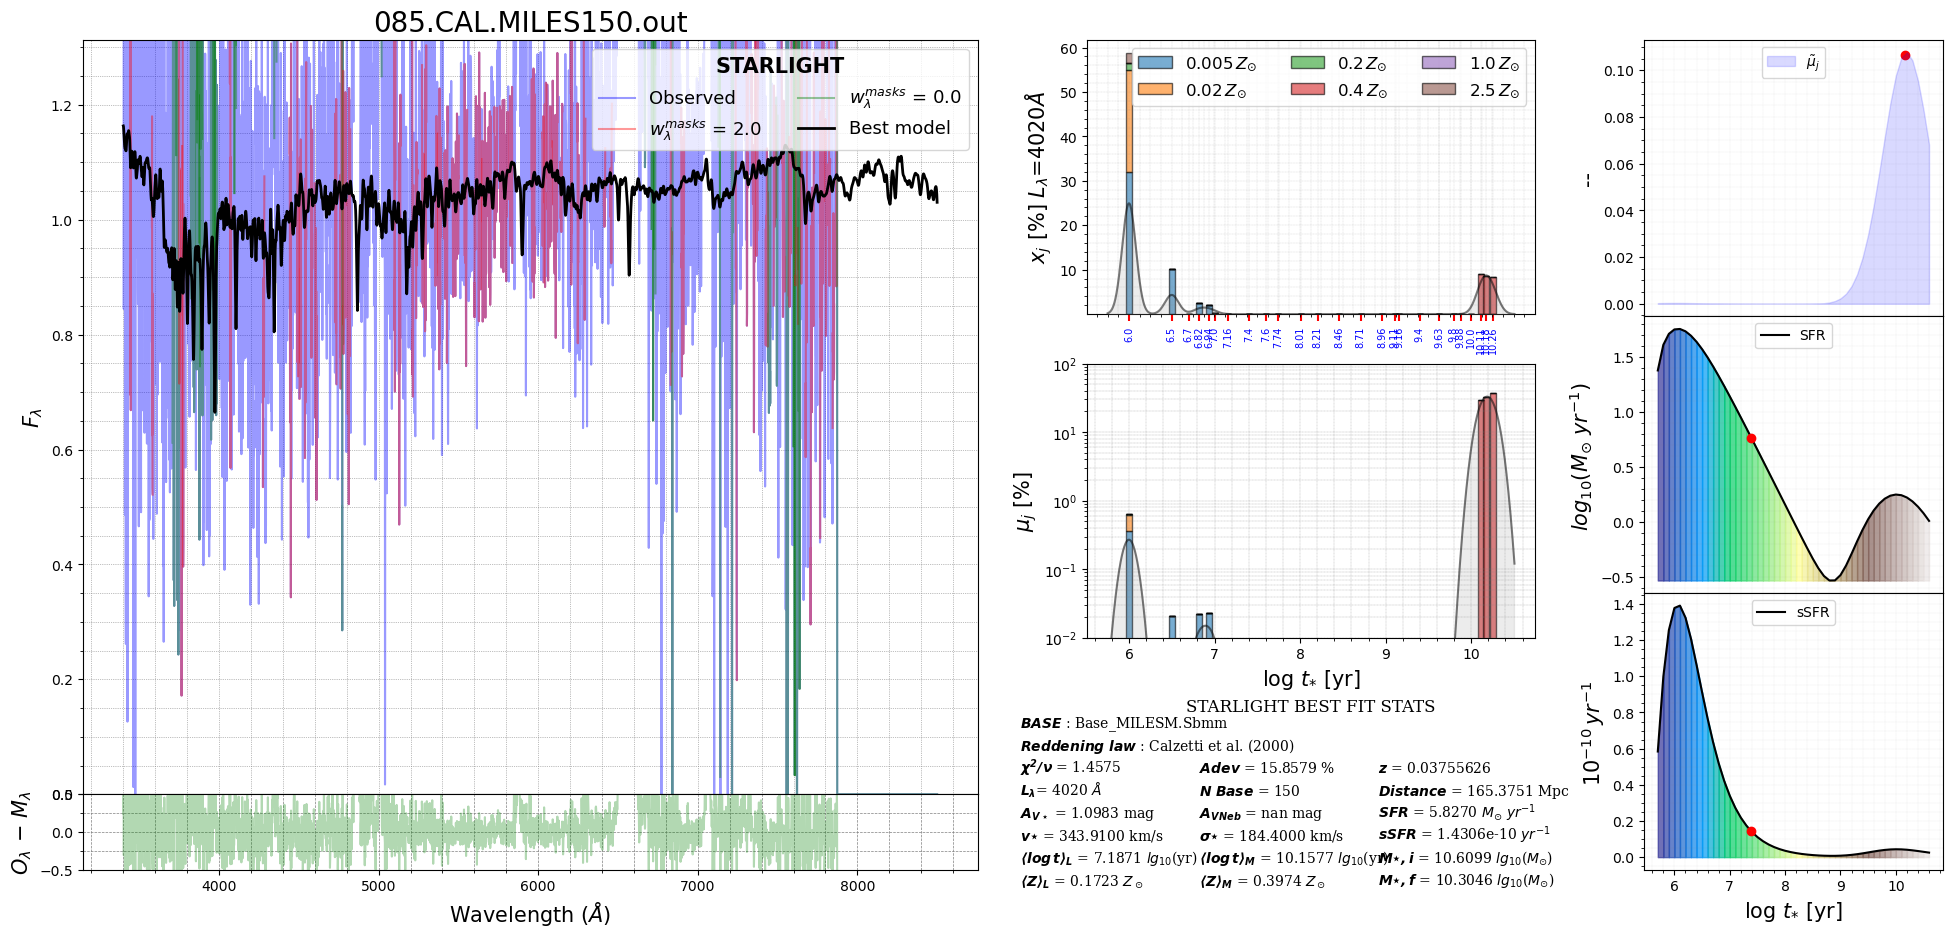

In [32]:
star_test.CompositePlot()

In [4]:
star_test = Starlight(home = '/home/holman/',file = '128.CAL.MILES150.out', distance = 0.06599529)

STARLIGHT .out file sucessfuly transformed to .fits format. Location: /home/holman/128.CAL.MILES150.fits


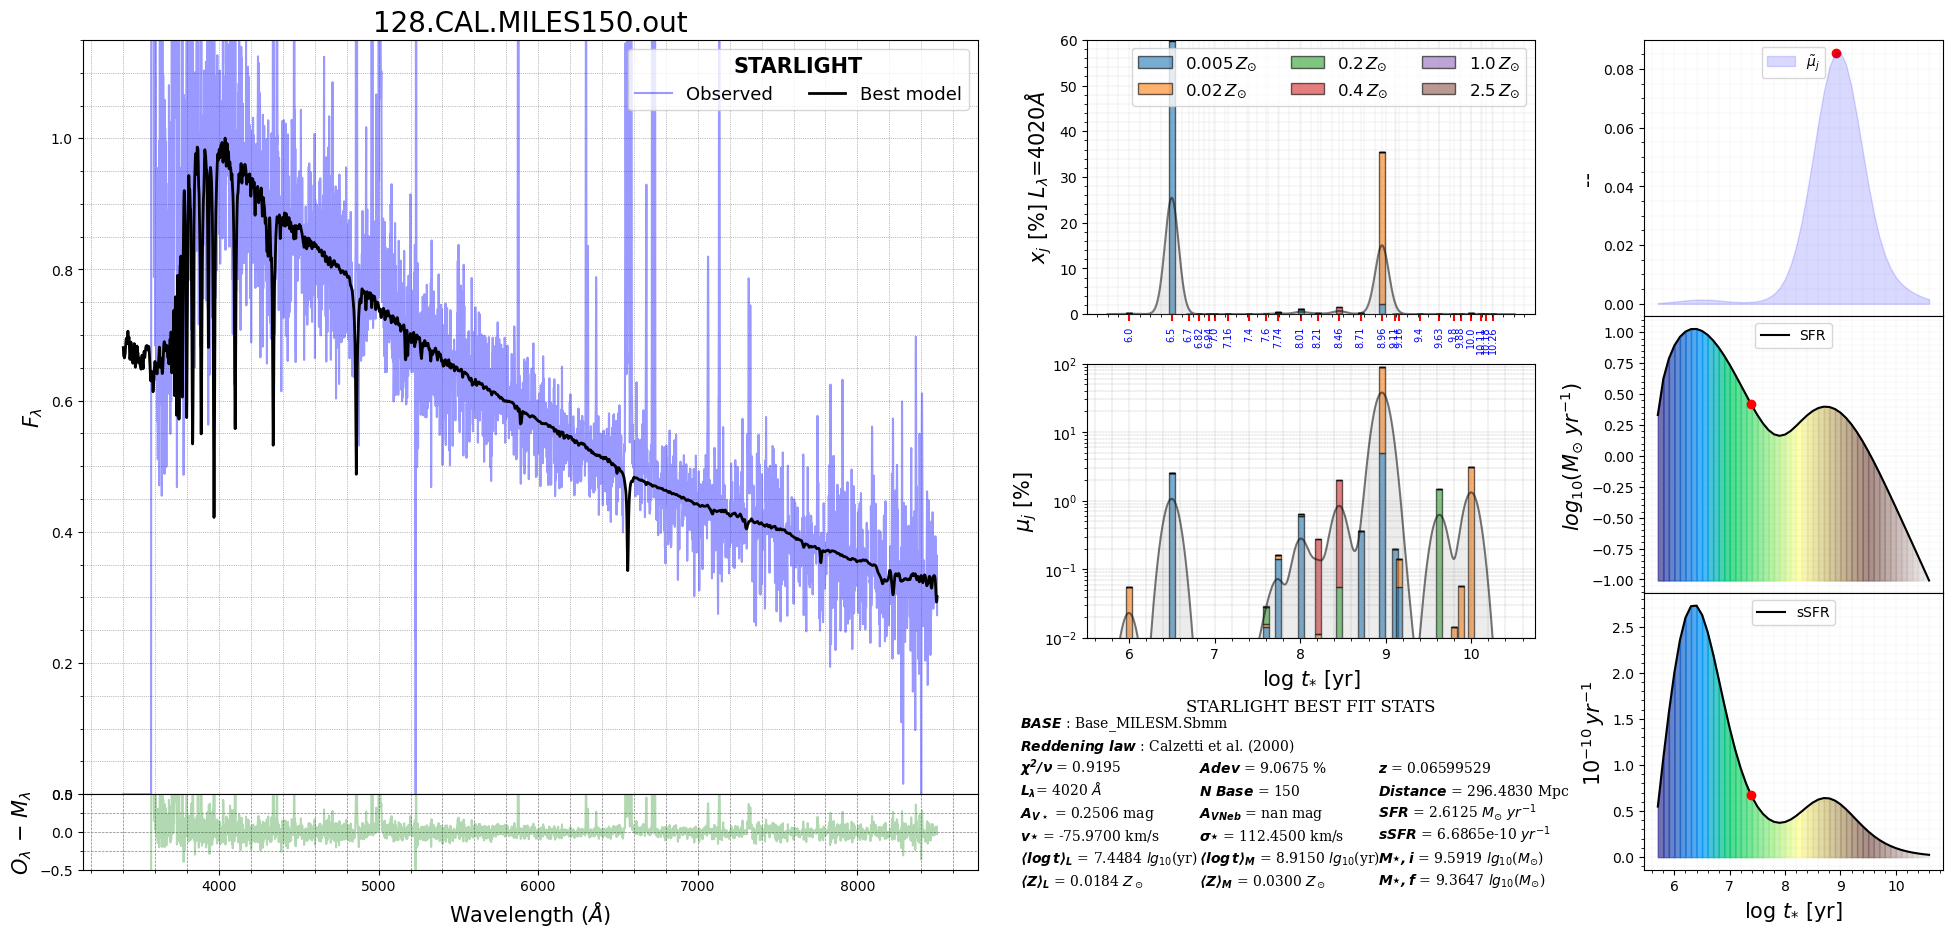

In [5]:
star_test.CompositePlot()

In [144]:
ln_4150 = Starlight(home = '/home/holman/Documents/CIMAT/StarLightv05/outputs/prefit2/',file = '005.CAL.MILES45.out')
ln_4150.metadata

No distance provided, no distance dependent calculations available. Distances have to be measured in u.Mpc, redshift as plain number.
STARLIGHT .fits file transformed before. Location: /home/holman/Documents/CIMAT/StarLightv05/outputs/prefit2/005.CAL.MILES45.fits


{'lambda_norm': 4150.0,
 'chi2': 1.48194,
 'adev': 5.01025,
 'red_law': 'CAL',
 'base_src': 'Base_45Prefit.Sbmm',
 'n_base': 45,
 'A_V': 1.6852,
 'A_Neb': nan,
 'v_star': 11.13,
 's_star': 403.84,
 'mean_logt_L': 6.0,
 'mean_logt_M': 6.0,
 'mean_Z_L': 2.5,
 'mean_Z_M': 2.5,
 'minitot': 16096.8,
 'mcortot': 16093.6}

In [ ]:

ln_5100.metadata

No distance provided, no distance dependent calculations available. Distances have to be measured in u.Mpc, redshift as plain number.
STARLIGHT .fits file transformed before. Location: /home/holman/Documents/CIMAT/StarLightv05/outputs/prefit/005.CAL.MILES45.fits


{'lambda_norm': 5100.0,
 'chi2': 0.689888,
 'adev': 3.85686,
 'red_law': 'CAL',
 'base_src': 'Base_45Prefit.Sbmm',
 'n_base': 45,
 'A_V': -1.0,
 'A_Neb': nan,
 'v_star': -10.26,
 's_star': 158.1,
 'mean_logt_L': 8.31583936253146,
 'mean_logt_M': 9.911358709380508,
 'mean_Z_L': 1.1376281734313345,
 'mean_Z_M': 0.24590874245227967,
 'minitot': 169295.0,
 'mcortot': 85827.4}

No distance provided, no distance dependent calculations available. Distances have to be measured in u.Mpc, redshift as plain number.
STARLIGHT .fits file transformed before. Location: /home/holman/Documents/CIMAT/StarLightv05/outputs/prefit/121.CAL.MILES45.fits
No distance provided, no distance dependent calculations available. Distances have to be measured in u.Mpc, redshift as plain number.
STARLIGHT .fits file transformed before. Location: /home/holman/Documents/CIMAT/StarLightv05/outputs/prefit2/121.CAL.MILES45.fits


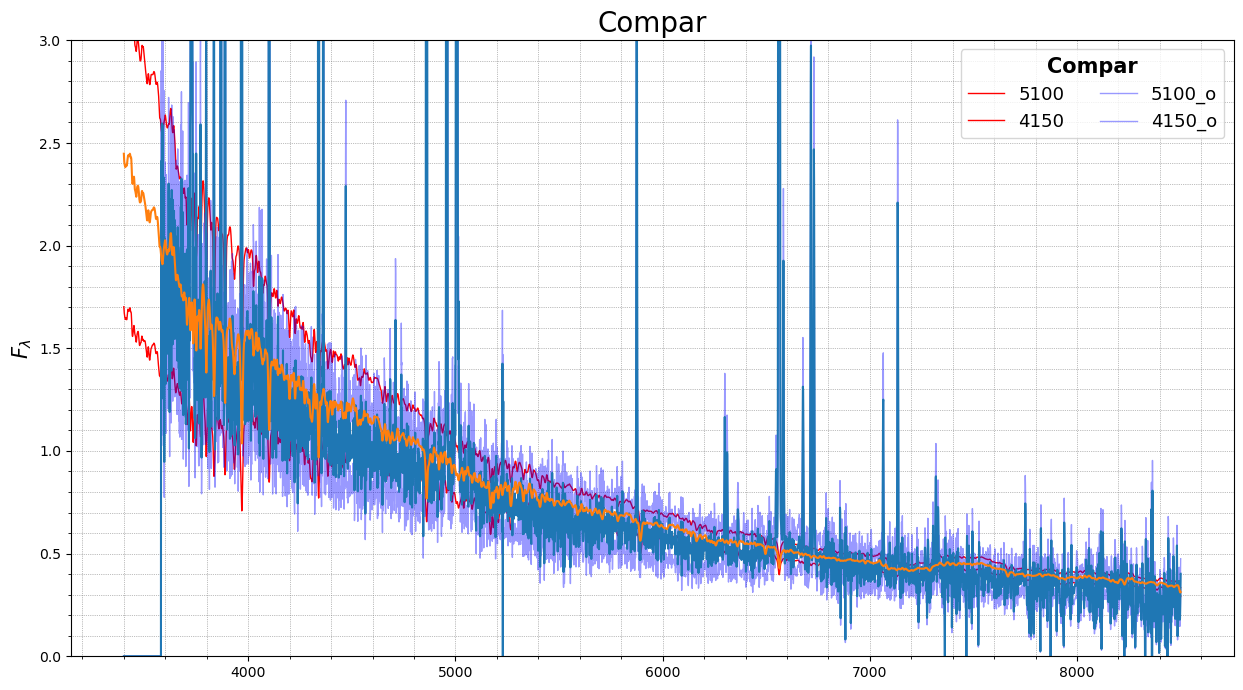

In [167]:
ln_5100 = Starlight(home = '/home/holman/Documents/CIMAT/StarLightv05/outputs/prefit/',file = '121.CAL.MILES45.out')
ln_4150 = Starlight(home = '/home/holman/Documents/CIMAT/StarLightv05/outputs/prefit2/',file = '121.CAL.MILES45.out')

obs_ = [ln_5100.spectrum_bestfit['Flux_obs'],ln_4150.spectrum_bestfit['Flux_obs']]
mean_obs = np.mean(obs_ , axis=0)

mod_ = [ln_5100.spectrum_bestfit['Flux_syn'],ln_4150.spectrum_bestfit['Flux_syn']]
mean_mod = np.mean(mod_ , axis=0)


fig, ax_t = plt.subplots(figsize=(15, 8))
ln_5100.BestFitSpectrum(ax=ax_t,label='5100',color='red'   , linewidth = 1.0)
ln_4150.BestFitSpectrum(ax=ax_t,label='4150',color='red'   , linewidth = 1.0)
ln_5100.ObservedSpectrum(ax=ax_t,label='5100_o',color='blue'   , linewidth = 1.0)
ln_4150.ObservedSpectrum(ax=ax_t,label='4150_o',color='blue'   , linewidth = 1.0)
ax_t.plot(ln_5100.spectrum_bestfit['Lambda'],mean_obs)
ax_t.plot(ln_5100.spectrum_bestfit['Lambda'],mean_mod)
#star_test2.BestFitSpectrum(ax=ax_t,label='STARLIGHT006',color='red')
ax_t.minorticks_on()
ax_t.tick_params(axis='x',which='major',labelbottom='off')
ax_t.set_ylim(0,3.0)
ax_t.set_title('Compar',fontsize=20)
ax_t.legend(loc='upper right',ncol=2, title = 'Compar', fontsize=13,title_fontproperties = {'weight':'bold', "size":15})
ax_t.set_ylabel(r'$F_\lambda$', fontsize=15)
ax_t.grid(True, which="both", ls=":", color = 'gray', linewidth = 0.5)

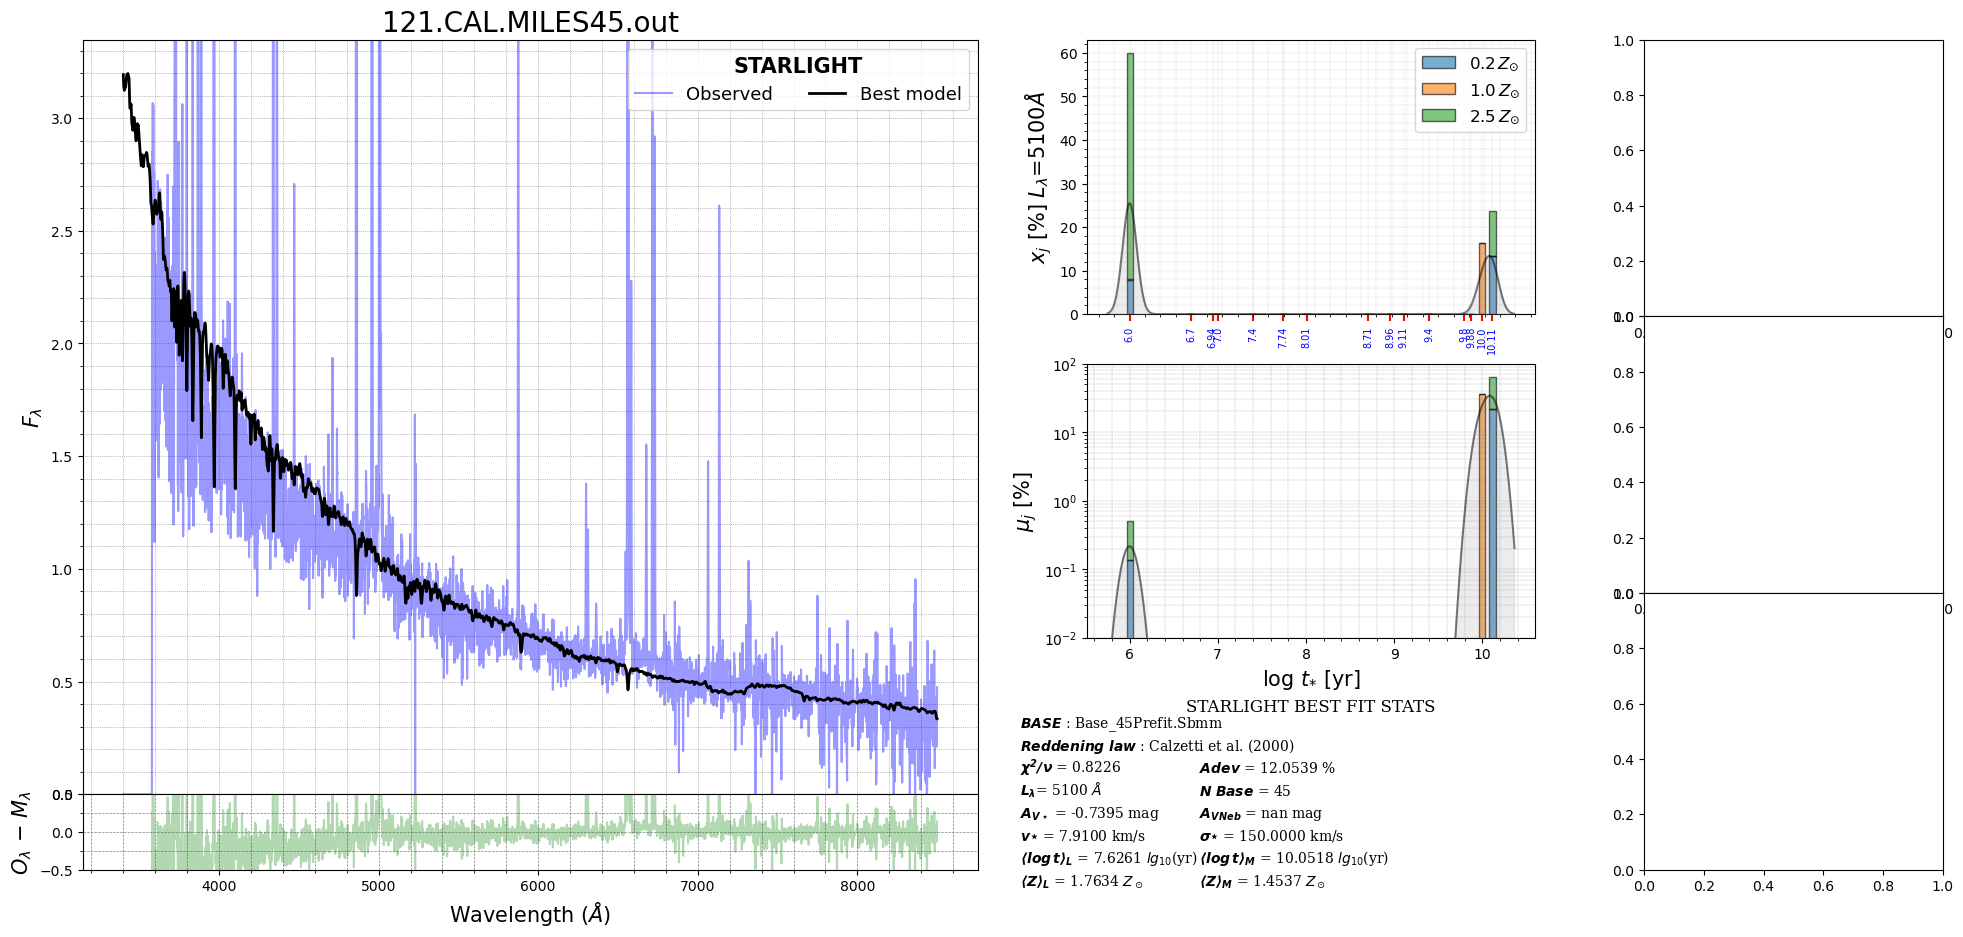

In [170]:
ln_5100.CompositePlot()

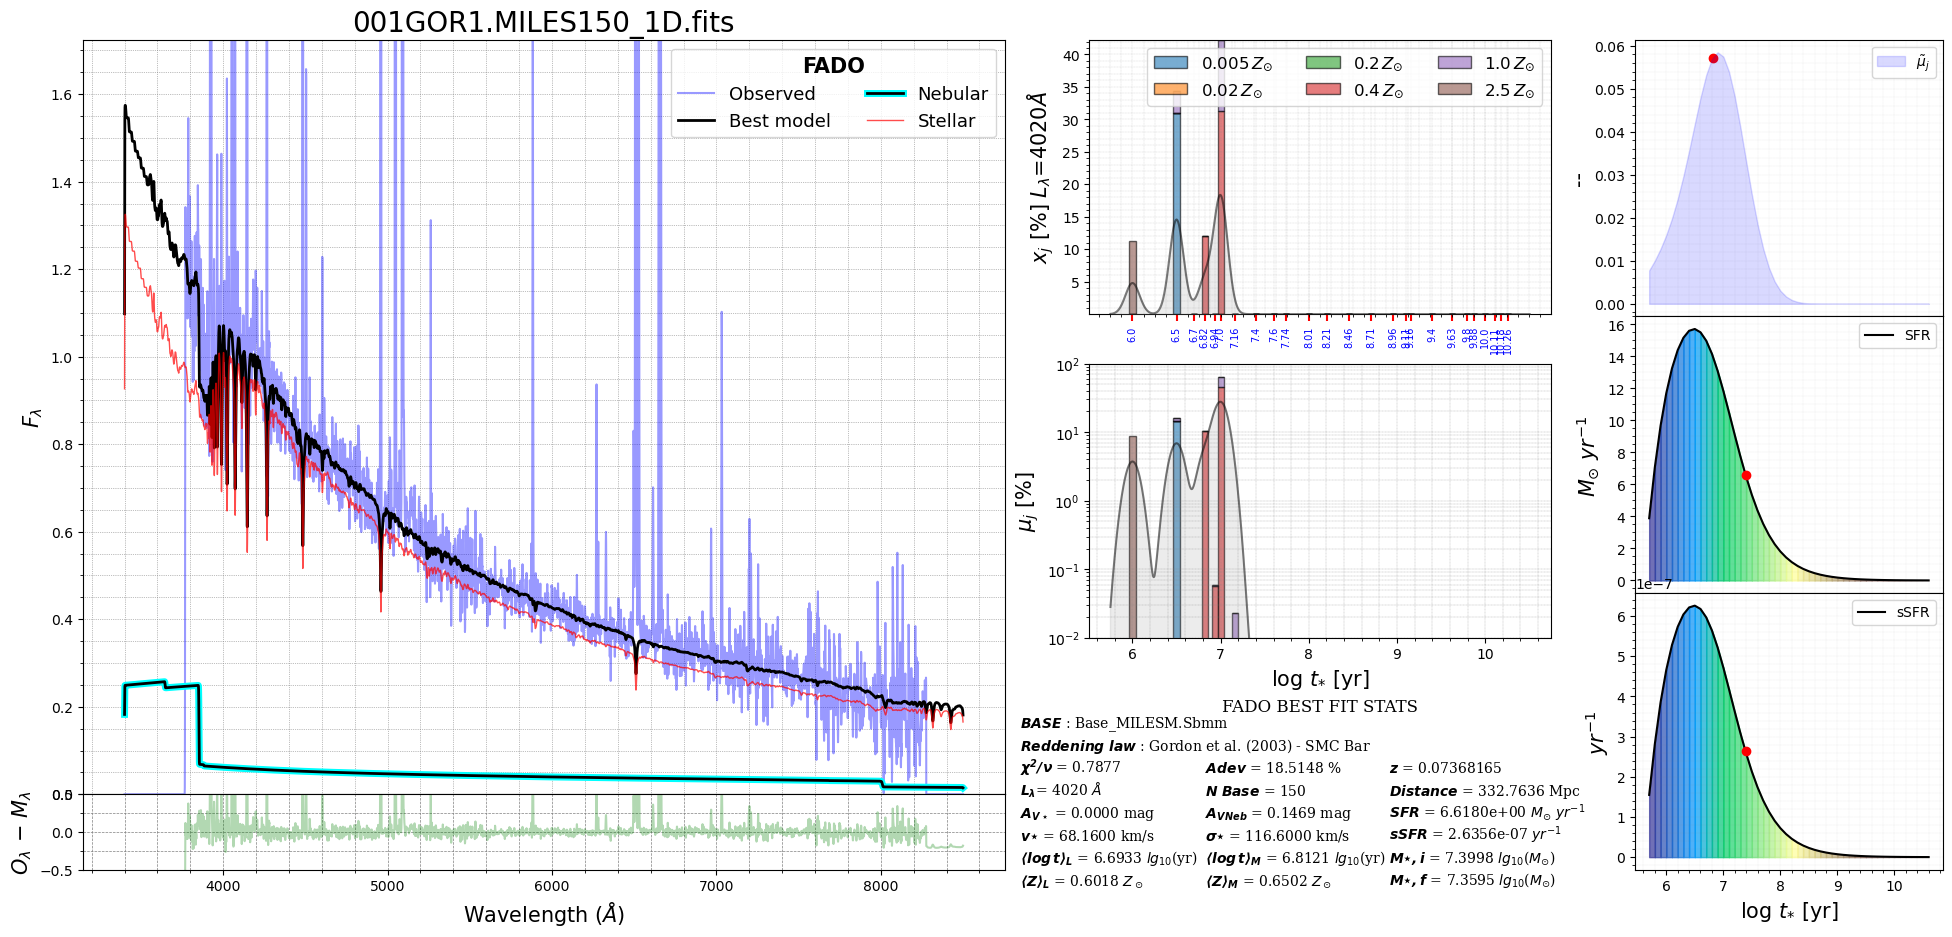

In [67]:
fado_test = Fado(home = '/home/holman/Documents/CIMAT/FADOv1b/o_FR4020/',file = '001GOR1.MILES150_1D.fits', distance = 0.07368165)
fado_test.CompositePlot()

STARLIGHT .fits file transformed before. Location: /home/holman/Documents/CIMAT/spec422166.fits


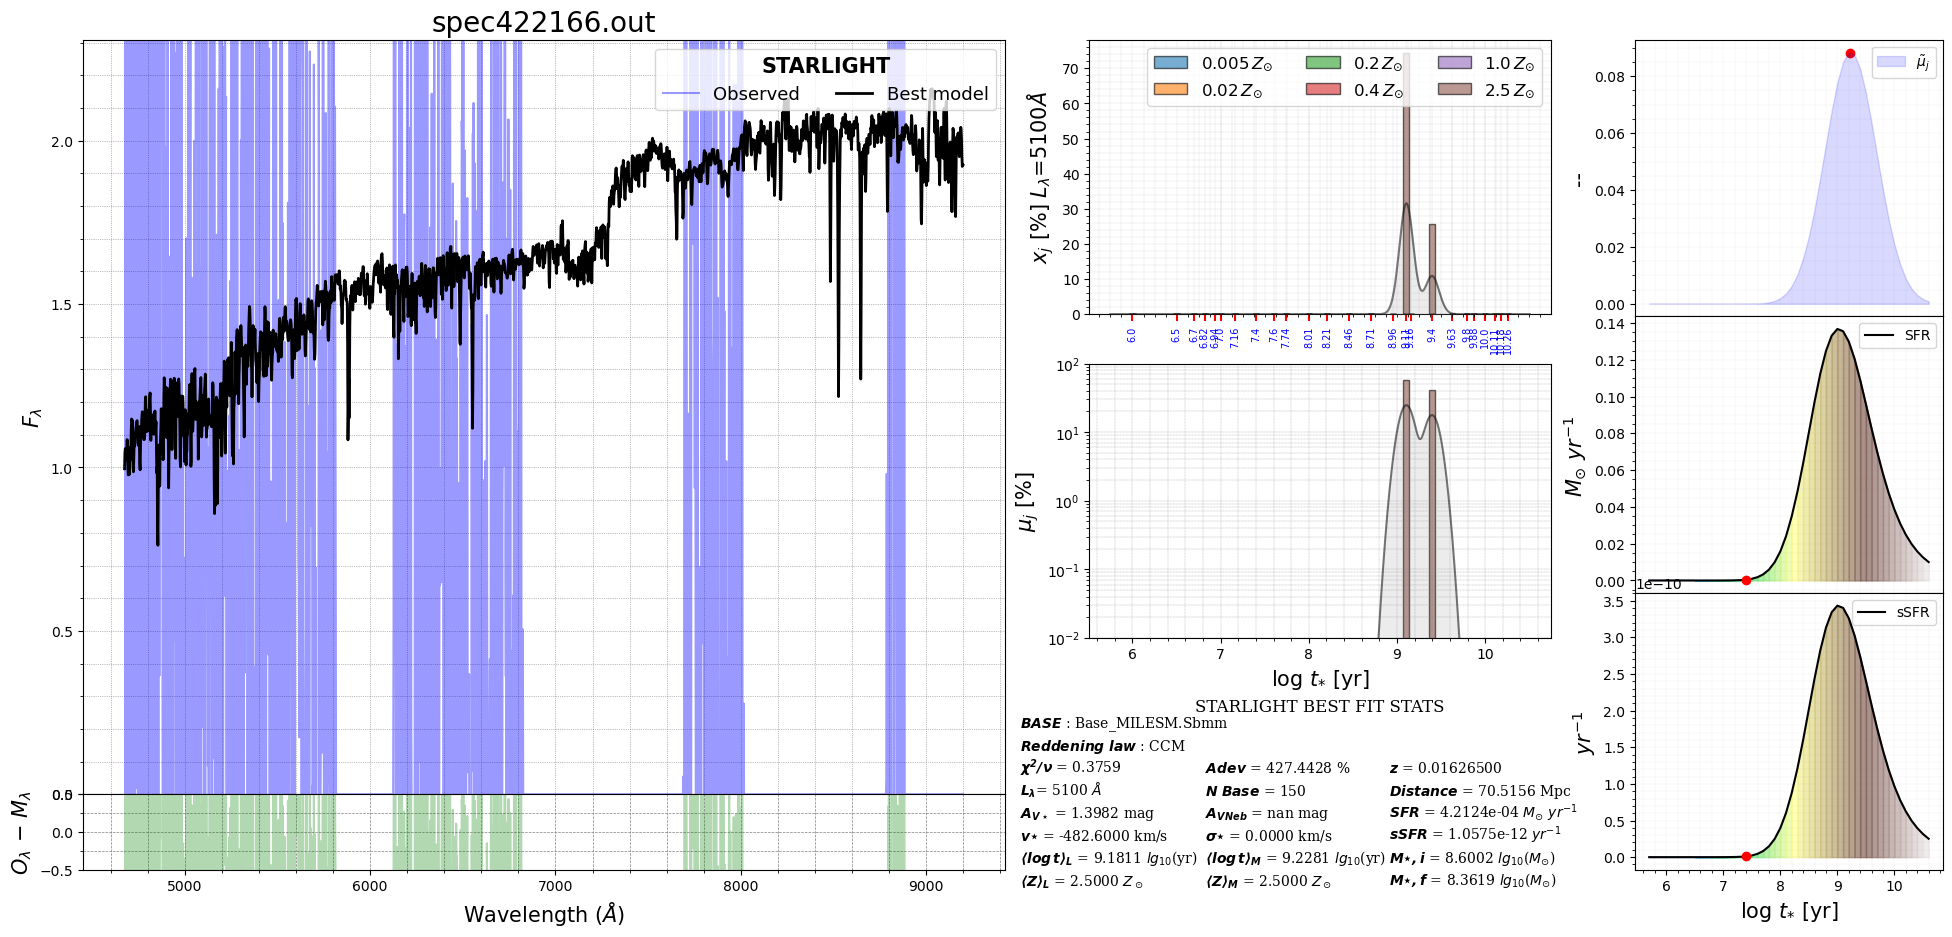

In [63]:
Jim1 = Starlight(home = '/home/holman/Documents/CIMAT/',file = 'spec422166.out', distance = 0.016265)
Jim1.CompositePlot()

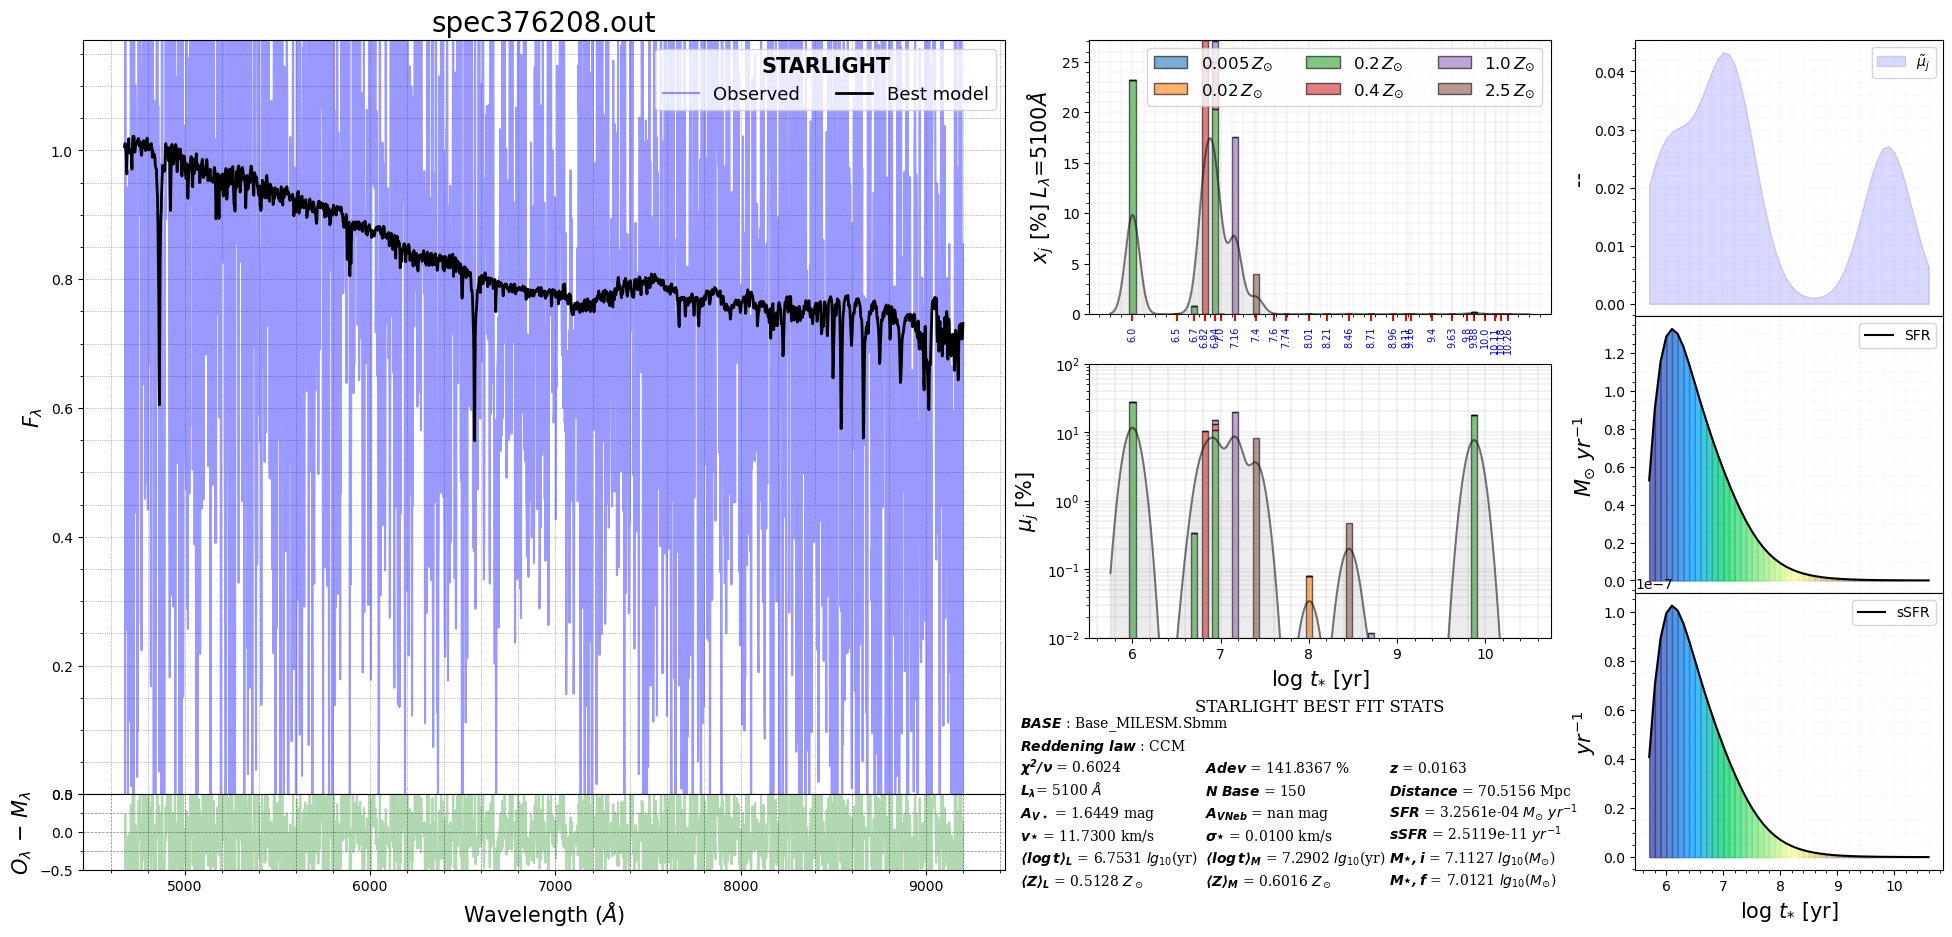

In [51]:
fado_test = Fado(home = '/home/holman/FADOv1b/o_FR4020/',file = '001CALR.MILES150_1D.fits')
star_test = Starlight(home = '/home/holman/StarLightv05/outputs/FR4020/',file = '017.CAL.MILES150.out')
star_test2 = Starlight(home = '/home/holman/StarLightv05/outputs/FR4020/',file = '012.CAL.MILES150.out')

STARLIGHT .out file sucessfuly transformed to .fits format. Location: /home/holman/StarLightv05/outputs/FR4020/017.CAL.MILES150.fits
STARLIGHT .fits file transformed before. Location: /home/holman/StarLightv05/outputs/FR4020/012.CAL.MILES150.fits


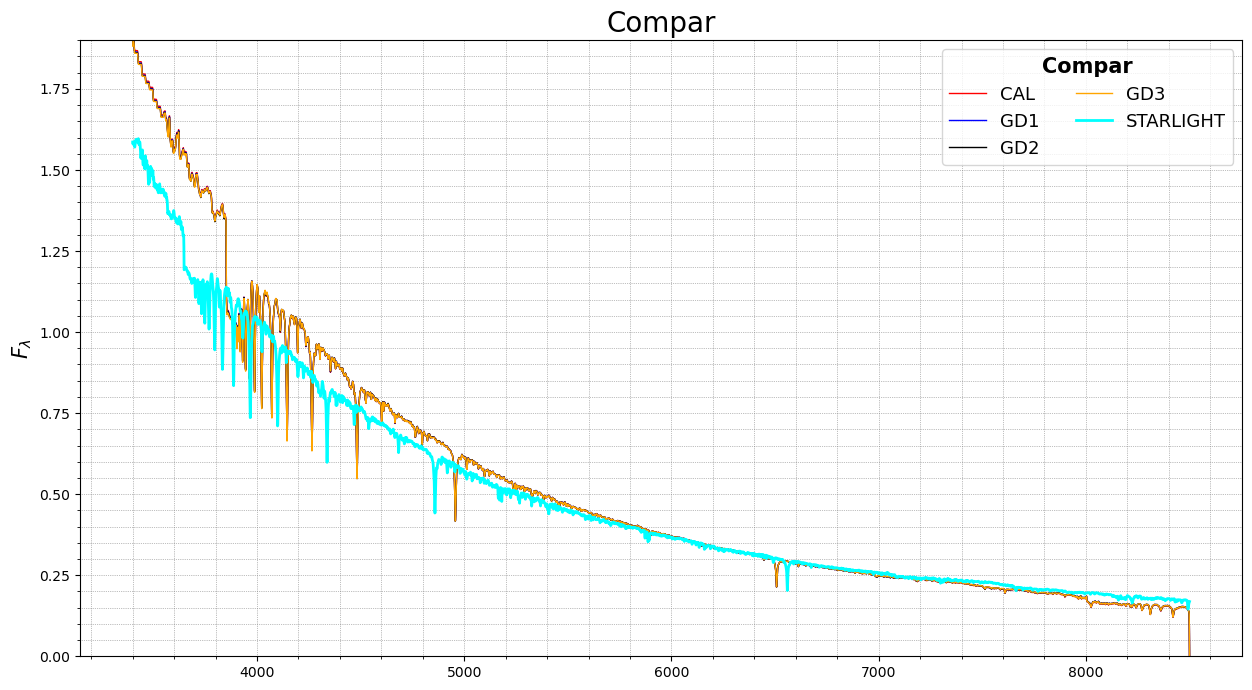

In [52]:
cho = '017'

fado_rl1 = Fado(home = '/home/holman/FADOv1b/o_FR4020/',file = f'{cho}CALR.MILES150_1D.fits')
fado_rl2 = Fado(home = '/home/holman/FADOv1b/o_FR4020/',file = f'{cho}GOR1.MILES150_1D.fits')
fado_rl3 = Fado(home = '/home/holman/FADOv1b/o_FR4020/',file = f'{cho}GOR2.MILES150_1D.fits')
fado_rl4 = Fado(home = '/home/holman/FADOv1b/o_FR4020/',file = f'{cho}GOR3.MILES150_1D.fits')


fig, ax_t = plt.subplots(figsize=(15, 8))
fado_rl1.BestFitSpectrum(ax=ax_t,label='CAL',color='red'   , linewidth = 1.0)
fado_rl2.BestFitSpectrum(ax=ax_t,label='GD1',color='blue'  , linewidth = 1.0)
fado_rl3.BestFitSpectrum(ax=ax_t,label='GD2',color='black' , linewidth = 1.0)
fado_rl4.BestFitSpectrum(ax=ax_t,label='GD3',color='orange', linewidth = 1.0)
star_test.BestFitSpectrum(ax=ax_t,label='STARLIGHT',color='cyan')
#star_test2.BestFitSpectrum(ax=ax_t,label='STARLIGHT006',color='red')
ax_t.minorticks_on()
ax_t.tick_params(axis='x',which='major',labelbottom='off')
ax_t.set_ylim(0,1.9)
ax_t.set_title('Compar',fontsize=20)
ax_t.legend(loc='upper right',ncol=2, title = 'Compar', fontsize=13,title_fontproperties = {'weight':'bold', "size":15})
ax_t.set_ylabel(r'$F_\lambda$', fontsize=15)
ax_t.grid(True, which="both", ls=":", color = 'gray', linewidth = 0.5)

<Axes: xlabel='log $t_{*}$ [yr]', ylabel='$\\mu_{j}$ [%]'>

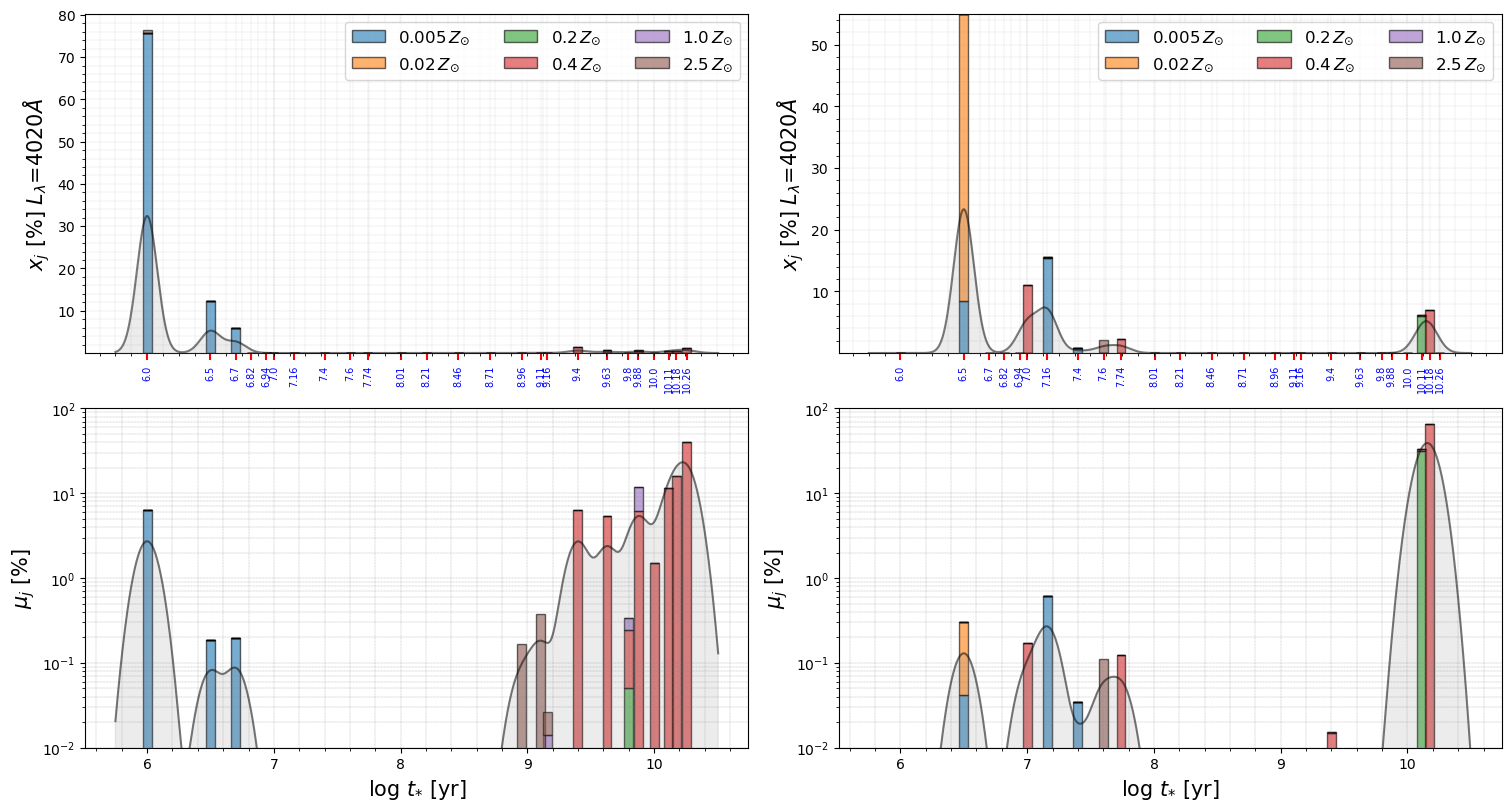

In [360]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 8), layout="constrained")

star_test.SSP_by_light(ax=axs[0, 0],single=False)
fado_test.SSP_by_light(ax=axs[0, 1],single=False)
star_test.SSP_by_mass(ax=axs[1, 0],single=False)
fado_test.SSP_by_mass(ax=axs[1, 1],single=False)

In [62]:


class StarlightProcessor:
    def __init__(self, redshift, fwhm=1.0, n_bins=50, ddt=0.1, time_ini=5.7):
        """
        Inicializa los parámetros físicos para el cálculo de SFH#[cite: 6, 8].
        """
        self.redshift = redshift
        self.fwhm = fwhm
        self.sigma = fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0))) #[cite: 8]
        self.n_bins = n_bins
        self.ddt = ddt
        self.time_ini = time_ini
        
        # Metalicidades y edades fijas según la base de bases de Starlight #[cite: 40]
        self.Z_met = np.array([0.0001, 0.0004, 0.0040, 0.0080, 0.0200, 0.0500]) #[cite: 40]
        self.age_base = np.unique(star_test.population_vector['age_j'])
        #self.age_base = np.array([
        #    1.00e6, 3.16e6, 5.01e6, 6.61e6, 8.71e6, 1.00e7, 1.445e7, 2.512e7, 
        #    4.00e7, 5.50e7, 1.0152e8, 1.609e8, 2.8612e8, 5.088e8, 9.0479e8, 
        #    1.27805e9, 1.434e9, 2.50e9, 4.25e9, 6.25e9, 7.50e9, 1.00e10, 
        #    1.30e10, 1.50e10, 1.80e10
        #]) #[cite: 40, 41]

    def get_luminosity_distance(self):
        """
        Calcula la distancia de luminosidad (DL) en cm usando una cosmología plana#[cite: 11, 46].
        H0=70, OM=0.3, OL=0.7#[cite: 46].
        """
        c = 299792.458 # km/s #[cite: 47]
        H0 = 70.0
        OM = 0.3
        OL = 0.7
        n = 1000
        
        dz = self.redshift / n
        z_steps = np.linspace(0, self.redshift, n)
        ez = np.sqrt(OM * (1 + z_steps)**3 + OL)
        integral = np.sum(dz / ez)
        
        dc = (c / H0) * integral #[cite: 49]
        dl_mpc = dc * (1 + self.redshift) #[cite: 52]
        
        # Convertir Mpc a cm #[cite: 12]
        dl_cm = dl_mpc * 1.0e6 * 3.086e16 * 1.0e2 #[cite: 12]
        return dl_cm

    def extract_starlight_out(self, file_path):
        """
        Extrae datos del archivo .out de STARLIGHT#[cite: 27].
        """
        with open(file_path, 'r') as f:
            lines = f.readlines()

        # Extraer escalares usando los índices del archivo #[cite: 42, 43, 44]
        fnor = float(lines[25].split()[0])
        sn = float(lines[30].split()[0])
        chi2 = float(lines[49].split()[0])
        minitot = float(lines[54].split()[0])
        mcortot = float(lines[55].split()[0])

        # Extraer la matriz de poblaciones (líneas 64 a 213) #[cite: 42]
        # x_j, mini, mcor, mstar
        pop_data = []
        for i in range(63, 213):
            parts = lines[i].split()
            if len(parts) >= 4:
                pop_data.append([float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])])
        
        pop_matrix = np.array(pop_data) # [150, 4]
        mini_vector = pop_matrix[:, 1] # Segunda columna es mini #[cite: 25, 35]
        
        return sn, minitot, mcortot, mini_vector

    def process(self, file_path):
        # 1. Obtener datos de entrada
        sn, minitot, mcortot, xx = self.extract_starlight_out(file_path)
        dl = self.get_luminosity_distance()
        
        # 2. Configurar bins de tiempo (log10) #[cite: 15]
        dt = self.time_ini + np.arange(self.n_bins) * self.ddt
        t_low = dt - (self.ddt / 2.0)
        t_upp = dt + (self.ddt / 2.0)
        
        # 3. Calcular Kernel de suavizado (reemplaza subrutina kernel y myerfun) #[cite: 15, 16]
        # Logaritmo de las edades de la base
        a_j = np.log10(self.age_base)
        a_j_repeated = np.tile(a_j, 6) # Para las 6 metalicidades #[cite: 15]
        
        kernel = np.zeros((150, self.n_bins))
        for j in range(self.n_bins):
            u_l = (dt[j] - (self.ddt/2.0) - a_j_repeated) / (np.sqrt(2.0) * self.sigma)
            u_u = (dt[j] + (self.ddt/2.0) - a_j_repeated) / (np.sqrt(2.0) * self.sigma)
            
            # Usamos la función error de scipy (erf) que es estable #[cite: 2, 77]
            er1 = erf(u_l)
            er2 = erf(u_u)
            
            # Normalización del kernel #[cite: 16]
            u_l_norm = (dt[0] - self.ddt/2.0 - a_j_repeated) / (np.sqrt(2.0) * self.sigma)
            u_u_norm = (dt[-1] + self.ddt/2.0 - a_j_repeated) / (np.sqrt(2.0) * self.sigma)
            auxden = erf(u_u_norm) - erf(u_l_norm)
            
            kernel[:, j] = (er2 - er1) / auxden

        # 4. Calcular mu (fracción de masa) #[cite: 17]
        mu = 0.01 * np.dot(xx, kernel)
        
        # 5. Masas totales en M_sun #[cite: 21]
        conv_factor = (1.0e-16) * (4.0 * np.pi * (dl**2.0)) * (1.0 / 3.826e33)
        mitot = minitot * conv_factor
        mctot = mcortot * conv_factor
        
        # 6. SFR y sSFR #[cite: 21]
        p = np.cumsum(mu)
        ssfr = p / (10.0**dt)
        sfr = ssfr * mitot
        
        return {
            "dt": dt,           # Eje de tiempo (log10 age)
            "mu": mu,           # Fracción de masa suavizada
            "sfr": sfr,         # Star Formation Rate
            "ssfr": ssfr,       # specific SFR
            "log_mitot": np.log10(mitot),
            "log_mctot": np.log10(mctot),
            "sn": sn
        }

# --- EJEMPLO DE USO ---
if __name__ == "__main__":
    # Instanciar con el redshift del objeto #[cite: 8]
    processor = StarlightProcessor(redshift=0.01788816)
    
    # Procesar el archivo
    results = processor.process('/home/holman/StarLightv05/005.CAL.MILES150.out')
    
    # Ahora tienes arrays de numpy listos
    print(f"Masa Inicial (log): {results['log_mctot']:.4f}")
    print(f"Masa Inicial (log): {results['log_mitot']:.4f}")
    print(f"Forma del array SFR: {results['sfr'].shape}")
    print(f"SNR: {results['sn']}")
    
    # Ejemplo: Acceder a los datos de mu (antiguo result1.dat)
    mu_array = results['mu']

Masa Inicial (log): 8.8354
Masa Inicial (log): 9.0764
Forma del array SFR: (50,)
SNR: 27.707
